In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import re
import seaborn as sns
from scipy import stats


In [2]:

def bar_plot(ax, col, color):
    counts = omni_filled[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=color, alpha=0.8)
    ax.set_title(f'{col}\n({omni_filled[col].nunique()} unique values)', fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.set_xticks(ax.get_xticks()[::max(1, len(counts)//8)])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def bar_plot_labeled(ax, col, color, labels):
    counts = omni_raw[col].value_counts().sort_values()
    yticklabels = [f'{int(k)} ({labels.get(int(k), "")})' for k in counts.index]
    ax.barh(range(len(counts)), counts.values, color=color, alpha=0.8)
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels(yticklabels, fontsize=8)
    ax.set_title(f'{col}\n({omni_raw[col].nunique()} unique values)', fontsize=9)
    ax.set_xlabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def kde_plot(ax, col, color):
    omni_filled[col].dropna().plot.kde(ax=ax, color=color, lw=1.5)
    ax.set_title(f'{col}\n({omni_raw[col].nunique()} unique values)', fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def hist_plot(ax, col, color, xlabel=None, bins=100):
    data = omni_filled[col].dropna()
    ax.hist(data, bins=bins, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{col}\n({data.nunique()} unique values)', fontsize=9)
    ax.set_xlabel(xlabel or col)
    ax.set_ylabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)



# Geomagnetic Storm Prediction from Cosmic Ray Measurements

## Abstract
This project investigates whether ground-based cosmic ray neutron monitor data, combined with near-Earth solar wind parameters, can be used to forecast the intensity of geomagnetic storms several hours in advance. The target variable is the Disturbance Storm Time (Dst) index, a standard measure of geomagnetic activity. The domain is Space Weather — specifically CME-driven geomagnetic disturbances — over the period 1981–2023.  

Two data sources are used: hourly neutron count rates from the Lomnický štít station (LMKS), provided by Kisvárdai et al. (2025), and hourly solar wind parameters from the NASA OMNI dataset (Papitashvili & King, 2020). After joint cleaning and feature engineering, the merged dataset spans 364,728 hourly observations across solar cycles 21–25.

## Introduction

This project belongs to the field of *Space Weather* — the study of how solar activity affects near-Earth space and, consequently, technological infrastructure on the ground and in orbit. Severe geomagnetic storms can induce geomagnetically induced currents (GICs) in power grid infrastructure, disrupt satellite navigation and radio communications, accelerate orbital decay of low-Earth-orbit satellites, and pose radiation hazards to astronauts and high-altitude aviation. A forecast with several hours of lead time allows grid operators, satellite controllers, and mission planners to take protective action. The practical operational minimum is one hour; longer horizons of $6$–$24$ hours are actively sought by the space weather community `[ISH17]`.


### Domain Definition

A geomagnetic storm is not a single event but a chain of causally connected phenomena, each of which leaves a measurable trace.

**Stage 1 — Eruption at the Sun.** During periods of high solar activity, magnetically stressed regions on the solar surface can release large quantities of magnetized plasma into interplanetary space — a *coronal mass ejection* (CME). A CME is accompanied by a fast-forward shock wave propagating ahead of it. The overall level of solar activity follows an approximately $11$-year cycle, which means that the frequency and intensity of CMEs — and consequently of geomagnetic storms — is not constant over time but rises and falls with the cycle. 

<img src="images/fig1_chain.png" style="width:80%; max-width:700px"/>  

*Figure 1 — The Sun–L1–Earth chain. Synthetic illustration.*


**Stage 2 — Propagation through interplanetary space.** The CME and its preceding shock travel outward from the Sun at speeds ranging from $300$ to $2{,}000\ \text{km/s}$. As the shock propagates, it sweeps aside galactic cosmic rays — high-energy charged particles that arrive continuously at Earth from outside the solar system. This sweeping creates a temporary deficit of cosmic rays, called a **Forbush Decrease**, which can be detected at ground level by a neutron monitor hours before the CME itself arrives at Earth `[KIS25]`. The Forbush Decrease is therefore a precursor signal embedded in the cosmic ray record.  

<img src="images/fig2_forbush_dst.png" style="width:70%; max-width:600px"/>  

*Figure 2 — Synthetic Forbush Decrease and $D_{st}$ response. For illustration only.*  

**Stage 3 — Arrival at L1 and the solar wind parameters.** Before reaching Earth, the CME passes through the **L1 Lagrange point** — a gravitationally stable location in space approximately $1.5 \times 10^6\ \text{km}$ upstream of Earth, where the gravitational pull of the Sun and Earth balance the centrifugal force on an orbiting body. Spacecraft stationed at L1 have an unobstructed view of the incoming solar wind and measure its properties continuously in near-real time: the speed $V_{sw}\ [\text{km/s}]$, the proton density $n_p\ [\text{cm}^{-3}]$, the plasma temperature $T\ [\text{K}]$, and — most critically for storm prediction — the north-south component of the interplanetary magnetic field $B_z\ [\text{nT}]$ `[PAP20]`, `[KIN05]`. When $B_z$ is directed southward ($B_z < 0$) and remains so for an extended period, the solar wind couples efficiently to Earth's magnetosphere through a process called magnetic reconnection.

**Stage 4 — Energy injection into the magnetosphere.** The rate at which energy enters the magnetosphere depends on the interplanetary electric field:

$$E_y = -V_{sw} \cdot B_z \cdot 10^{-3} \quad [\text{mV/m}]$$

A large positive $E_y$ — produced by high solar wind speed combined with strong southward $B_z$ — drives energetic particles into a toroidal current circulating around Earth at altitudes of $2$–$9\ R_E$, known as the *ring current*. The intensification of this current depresses Earth's horizontal magnetic field at low latitudes. The classical description of this process is given by the Burton et al. (1975) equation `[BUR75]`:

$$\frac{dD_{st}}{dt} = Q(E_y) - \frac{D_{st}}{\tau}$$

where $Q(E_y)$ is the injection rate and $D_{st}/\tau$ is the natural decay of the ring current with characteristic time $\tau \approx 7$–$8$ hours. The injection function is:

$$Q(E_y) = \begin{cases} -4.4\,(E_y - 0.5) & \text{if } E_y > 0.5\ \text{mV/m} \\ 0 & \text{otherwise} \end{cases}$$

<img src="images/fig3_burton.png" style="width:60%; max-width:700px"/>  

*Figure 3 — Burton (1975) physical model `[BUR75]`. Synthetic $E_y(t)$ profile.*  


**Stage 5 — Ground-level response.** The depression of the horizontal magnetic field is recorded at a network of low-latitude observatories and averaged into the **Disturbance Storm Time ($D_{st}$) index** `[WDC]`, expressed in nanotesla ($\text{nT}$). This is the target variable of the present project. Storm severity is conventionally classified as:

$$D_{st} > -50\ \text{nT} \quad \text{(quiet)}$$
$$-100\ \text{nT} < D_{st} \leq -50\ \text{nT} \quad \text{(moderate storm)}$$
$$-200\ \text{nT} < D_{st} \leq -100\ \text{nT} \quad \text{(strong storm)}$$
$$D_{st} \leq -200\ \text{nT} \quad \text{(extreme storm)}$$

The decay time $\tau \approx 7$–$8$ hours from the Burton equation defines the natural timescale of storm evolution and motivates the choice of prediction horizons examined in this project. The physical travel time of a CME shock from the Sun to L1 ($1$–$4$ days) and the L1-to-Earth propagation time ($15$–$60$ minutes) jointly constrain the range of horizons for which ground-based and in-situ measurements can plausibly carry predictive information: between $1$ and approximately $72$ hours `[PAR10]`, `[ISH17]`.

### Prior Work

The Burton et al. (1975) equation `[BUR75]` established the classical physical relationship between $E_y$ and $D_{st}$, providing a physically interpretable baseline that remains in use today. More recent machine learning approaches have extended this to multi-hour prediction: Parnowski (2010) `[PAR10]` reports $R^2 > 0.90$ at $1$–$6$ hour horizons using OMNI solar wind parameters alone. The MagNet competition `[NAI23]` benchmarked a broad range of models — from linear regression to deep neural networks — achieving RMSE in the range of $11$–$15\ \text{nT}$ at a $1$-hour horizon. Hu et al. (2023) `[HU23]` applied multi-fidelity boosted neural networks with explicit prediction intervals, further demonstrating the value of uncertainty quantification in operational forecasting.

**Gap.** Most published models rely exclusively on in-situ solar wind measurements at L1, which provide at most $15$–$60$ minutes of natural lead time before the disturbance reaches Earth. The Forbush Decrease — described in Stage 2 above — offers a physically distinct signal that precedes the storm's main phase by several hours. Kisvárdai et al. (2025) `[KIS25]` analyzed $42$ years of neutron monitor data from the Lomnický štít station and found a Pearson correlation of $r = 0.314$ between the neutron flux and $D_{st}$ at a time shift of $7$–$21$ hours, and a predictive power score of $\text{PPS} = 0.22$. This suggests that the cosmic ray signal carries information about future storm intensity beyond what the instantaneous solar wind parameters alone capture.

**Contribution.** This project investigates whether combining cosmic ray neutron flux measurements `[KIS24]` with OMNI solar wind parameters `[PAP20]` can extend the useful prediction horizon and improve forecast skill relative to OMNI-only models.

**Scope.** The analysis is restricted to CME-driven storms over the period $1981$–$2023$. The dataset is not filtered by storm driver type — Co-rotating Interaction Region (CIR) driven storms, which follow a different physical mechanism and do not produce a Forbush Decrease precursor, remain in the record and represent a source of noise for the cosmic ray features. This is acknowledged as a limitation of the present study.


## Methods

This section states the pre-registered assumptions and known limitations of the study. All modelling decisions — feature engineering, train/validation/test split, and model selection — are declared here, before any data is loaded, to avoid post-hoc rationalisation.

### Assumptions

**Problem formulation.** The task is supervised regression: given a window of past observations ending at time $t$, predict $D_{st}(t + h)$ for a lead time $h \in \{1, 3, 7, 12, 21\}$ hours. These horizons span short-term operational forecasting ($1$–$3$ h), the Burton ring current decay timescale ($7$ h), and the upper range of the observed neutron–$D_{st}$ lag reported by Kisvárdai et al. (2025) `[KIS25]` ($21$ h). A secondary formulation treats the problem as binary classification — storm / no-storm — with threshold $D_{st} \leq -50\ \text{nT}$, following the NOAA moderate storm convention `[WDC]`.

**Hypotheses.**

- $H_{skill}$: A model trained on the differential neutron flux $\delta n(t)$ and OMNI solar wind parameters achieves $R^2 \geq 0.60$ at a lead time of $h = 7$ hours on the held-out test set (solar cycles 24–25, 2008–2023).
- $H_{gain}$: A model trained on OMNI solar wind parameters combined with $\delta n(t)$ achieves a higher $R^2$ at $h \geq 7$ hours than an equivalent model trained on OMNI parameters alone.

The differential neutron flux is defined as:

$$\delta n(t) = \frac{N(t) - N(t - w)}{N(t - w)}$$

where $N(t)$ is the hourly neutron count rate from the LMKS station `[KIS24]` and $w$ is the differencing window. A value of $w = 7$ hours is chosen on two grounds: Kisvárdai et al. (2025) `[KIS25]` find that the Pearson correlation between the LMKS neutron flux and $D_{st}$ is maximised at a time shift of $7$–$21$ hours; and the characteristic ring current decay time $\tau \approx 7$–$8$ hours from the Burton equation `[BUR75]` provides a physically motivated lower bound for this range.

**Success threshold.** The target threshold of $R^2 \geq 0.60$ at $h = 7$ hours is motivated by three reference points from the literature: Parnowski (2010) `[PAR10]` reports $R^2 > 0.90$ at $h = 1$–$6$ hours using OMNI alone, establishing an upper bound for short horizons; the MagNet competition `[NAI23]` reports RMSE of $11$–$15\ \text{nT}$ at $h = 1$ hour; and Kisvárdai et al. (2025) `[KIS25]` report a predictive power score of $\text{PPS} = 0.22$ for neutron flux alone, establishing that the cosmic ray signal has non-trivial but modest predictive value. Direct comparison across these studies is imperfect as the reported metrics differ. A threshold of $R^2 = 0.60$ at $h = 7$ hours represents a meaningful improvement over the cosmic-ray-only baseline while remaining below the OMNI-only performance at short horizons.

**Evaluation metrics.** Primary metric: $R^2$ (coefficient of determination). Secondary metrics: RMSE $[\text{nT}]$ and MAE $[\text{nT}]$. Given the strong class imbalance — quiet conditions ($D_{st} > -50\ \text{nT}$) dominate the record — a model that predicts values near zero at all times would achieve a deceptively high $R^2$. For this reason, evaluation is performed both on the full test set and separately on the storm subset ($D_{st} \leq -50\ \text{nT}$), reporting RMSE and MAE for each subset independently. For the classification formulation, the Precision-Recall curve and $F_1$ score are reported in preference to accuracy, since missing a storm (false negative) carries a higher operational cost than a false alarm.


### Limitations

**Single neutron monitor station.** The LMKS dataset represents measurements at a single point on Earth's surface (Lomnický štít, Slovakia, $2{,}634\ \text{m}$, geomagnetic cutoff rigidity $\approx 3.85\ \text{GV}$) `[KIS24]`. The amplitude of a Forbush Decrease depends on the relative geometry between the CME propagation direction and the observer. CMEs directed away from the Sun–Earth line may produce a weak or absent Forbush Decrease at LMKS even when they cause a significant geomagnetic storm.

**No CIR storm filtering.** The dataset is not filtered by storm driver type. Co-rotating Interaction Region (CIR) driven storms — which are caused by the interaction of fast and slow solar wind streams and do not produce a Forbush Decrease precursor — are present in the record and act as noise for the neutron flux features. Their removal would require an independent CME catalogue, which is outside the scope of this project.

**Sensor changes over 42 years.** The LMKS neutron monitor record spans 1981–2023 and covers multiple instrument upgrades. Long-term trends in the count rate baseline may reflect instrumental changes rather than physical variability. This is examined in IDA.

**Data leakage risk.** When constructing lag features $\delta n(t)$ and shifted $D_{st}$ targets, all transformations must be applied strictly within the training period before being applied to validation and test sets. Any normalisation or scaling parameters are fitted on the training set only.

**Forecast horizon constraint.** The analysis is restricted to horizons $h \leq 21$ hours. At longer horizons, the coherence of interplanetary structures degrades and the physical basis for prediction weakens `[ISH17]`.

## Initial Data Analysis (IDA)

Before any modelling can begin, we need to understand what we actually have. Two datasets covering 42 years of measurements — one from a satellite at L1, one from a neutron monitor in Slovakia — must be combined into a single clean record. This section documents what we find in the raw data: how complete it is, where the gaps are, whether the instruments changed over time, and whether there are physically extreme events that need special attention.

Both datasets are loaded in their raw form without any modifications. Shape, column names, and data types are inspected before any values are touched.


### Data Sources

Two datasets are used in this project.

**OMNI** `[PAP20]`, `[KIN05]` — hourly averages of near-Earth solar wind magnetic field and plasma parameters compiled by NASA/GSFC Space Physics Data Facility. The dataset integrates measurements from multiple spacecraft: ISEE-3 (1978–1982), IMP-8 (1973–2001), Wind (1994–present), and ACE (1998–present) as the primary sources for the period covered by this project. Data from L1 spacecraft (ISEE-3, Wind, ACE) are time-shifted to the expected magnetospheric arrival time before hourly averaging `[KIN05]`. Plasma parameters from different spacecraft are cross-normalized to Wind/SWE/NLF as the common baseline `[KIN05]`. IMP-8, which operated in a ~12-day geocentric orbit making 2–20 bow shock crossings per orbit, is the dominant source for 1982–1994 and is the primary cause of the elevated missing rate in that period `[KIN05]`. Column definitions and fill values are taken from the accompanying format file `omni2_6HWKguLfs2.fmt`.

The OMNI dataset is stored in a legacy ASCII fixed-width format inherited from Fortran-era scientific computing. In this format, the concept of `NaN` does not exist — every field must contain a number of a fixed width. Missing measurements are therefore encoded as physically impossible sentinel values (e.g. `999.9`, `9999.`, `99999`) that exactly fill the allocated field width. This convention is documented in King & Papitashvili (2005) `[KIN05]` and must be accounted for before any statistical analysis.


In [3]:
# Parse column names from fmt file
col_names = pd.read_fwf('data/input/omni2_6HWKguLfs2.fmt', skiprows=4, header=None)[1].tolist()

# Load data
omni_raw = pd.read_csv('data/input/omni2_6HWKguLfs2.lst', sep=r'\s+', header=None, names=col_names)
print("\n=== OMNI — first 5 rows ===")
display(omni_raw.head())
print("\n=== OMNI — shape ===")
print(omni_raw.shape)
print("\n=== OMNI — dtypes ===")
print(omni_raw.dtypes)


=== OMNI — first 5 rows ===


,YEAR,DOY,Hour,Bartels rotation number,ID for IMF spacecraft,ID for SW Plasma spacecraft,# of points in IMF averages,# of points in Plasma averag.,"Scalar B, nT","Vector B Magnitude,nT",...,"AU-index, nT",pc-index,Lyman_alpha,Proton flux (>1 Mev),Proton flux (>2 Mev),Proton flux (>4 Mev),Proton flux (>10 Mev),Proton flux (>30 Mev),Proton flux (>60 Mev),Flux FLAG
0,1981,335,0,2027,13,13,30,999,6.3,6.0,...,30,-0.2,0.009727,0.28,0.24,0.23,0.23,0.23,0.22,6
1,1981,335,1,2027,13,13,29,999,6.4,5.8,...,33,-0.2,0.009727,999999.99,99999.99,99999.99,99999.99,99999.99,99999.99,0
2,1981,335,2,2027,13,13,30,999,6.3,6.2,...,38,-0.2,0.009727,0.25,0.21,0.20,0.20,0.20,0.20,6
3,1981,335,3,2027,13,13,31,999,6.1,5.9,...,46,-0.2,0.009727,0.22,0.18,0.17,0.17,0.16,0.16,6
4,1981,335,4,2027,13,13,29,999,5.9,5.5,...,52,-0.1,0.009727,999999.99,99999.99,99999.99,99999.99,99999.99,99999.99,0



=== OMNI — shape ===
(365232, 57)

=== OMNI — dtypes ===
YEAR                               int64
DOY                                int64
Hour                               int64
Bartels rotation number            int64
ID for IMF spacecraft              int64
ID for SW Plasma spacecraft        int64
# of points in IMF averages        int64
# of points in Plasma averag.      int64
Scalar B, nT                     float64
Vector B Magnitude,nT            float64
Lat. Angle of B (GSE)            float64
Long. Angle of B (GSE)           float64
BX, nT (GSE, GSM)                float64
BY, nT (GSE)                     float64
BZ, nT (GSE)                     float64
BY, nT (GSM)                     float64
BZ, nT (GSM)                     float64
RMS_magnitude, nT                float64
RMS_field_vector, nT             float64
RMS_BX_GSE, nT                   float64
RMS_BY_GSE, nT                   float64
RMS_BZ_GSE, nT                   float64
SW Plasma Temperature, K         float64

**OMNI column groups** `[KIN05]`, `[PAP20]`:

The 57 columns are organised into eight groups following the structure of the format file `[KIN05]`.

**Time** (`YEAR`, `DOY`, `Hour`) — hourly timestamp encoded as year, day-of-year, and hour.

**Administrative** (`Bartels rotation number`, `ID for IMF spacecraft`, `ID for SW Plasma spacecraft`, `# of points in IMF averages`, `# of points in Plasma averag.`) — metadata identifying which spacecraft provided each hourly value and how many fine-scale points contributed to the average `[KIN05]`.

**IMF** (`Scalar B`, `Vector B`, `Lat./Long. angle`, `Bx GSE/GSM`, `By GSE/GSM`, `Bz GSE/GSM`) — the interplanetary magnetic field carried by the solar wind. The north-south component $B_z$ in GSM coordinates is the primary driver of geomagnetic storms via the Burton injection function `[BUR75]`.

**RMS** (`RMS_magnitude`, `RMS_field_vector`, `RMS_Bx`, `RMS_By`, `RMS_Bz`) — standard deviations of the 1-minute IMF values within each hourly average, as defined in `[KIN05]`.

**Solar Wind Plasma** (`T_p`, `n_p`, `V_{sw}`, `phi-V`, `theta-V`, `Alpha/Prot. ratio`) — bulk properties of the solar wind plasma. Solar wind speed $V_{sw}$ combined with $B_z$ determines the interplanetary electric field $E_y = -V_{sw} \cdot B_z \cdot 10^{-3}$ `[BUR75]`.

**Sigma** (`sigma-T`, `sigma-n`, `sigma-V`, `sigma-phi-V`, `sigma-theta-V`, `sigma-ratio`) — standard deviations of the 1-minute plasma values within each hourly average `[KIN05]`.

**Derived** (`Flow pressure`, `E field`, `Plasma Beta`, `Alfvén mach`, `Magnetosonic mach`, `Quasy-Invariant`) — quantities computed from IMF and plasma measurements following the formulas in `[KIN05]`.

**Solar Activity** (`R (Sunspot No.)`, `f10.7_index`, `Lyman_alpha`) — daily solar activity indices assigned to each hour of the relevant day `[KIN05]`.

**Geomagnetic Indices** (`Kp index`, `Dst-index, nT`, `ap_index, nT`, `AE-index, nT`, `AL-index, nT`, `AU-index, nT`, `pc-index`) — ground-based indices of magnetospheric activity. `Dst-index, nT` is the target variable of this project `[WDC]`.

**Proton Flux** (`Proton flux >1/2/4/10/30/60 MeV`, `Flux FLAG`) — energetic particle fluxes from IMP and GOES spacecraft `[KIN05]`. The `Flux FLAG` encodes the degree of magnetospheric contamination in the proton flux measurements, with fill value `-1` indicating records not checked for magnetospheric contribution `[KIN05]`.

> **Observations — OMNI:**
> - Shape: 365,232 rows × 57 columns.
> - Column names loaded directly from `omni2_6HWKguLfs2.fmt` `[KIN05]`.
> - Time and index columns are `int64`; all physical measurements are `float64`, consistent with the format file.
> - Missing data is not encoded as `NaN` — sentinel fill values are used throughout, as documented in `[KIN05]`.
> - `# of points in Plasma averag.` shows `999` in the first rows — the documented fill value for this field `[KIN05]`, indicating no plasma data were available.
> - `Flux FLAG` shows values `6` and `0` in the first rows: `6` indicates no magnetospheric contribution; `0` indicates magnetospheric contribution in all channels `[KIN05]`.

The 57 OMNI columns are organised into nine physical groups following the structure of the format file `[KIN05]`. These groups are used throughout the analysis to separate physical measurements from metadata and quality indicators.


In [4]:
# ── IDA: Physical column groups per [KIN05] ───────────────────────────────────

omni_groups = {
    'Time': [
        'YEAR', 'DOY', 'Hour',
    ],
    'Administrative': [
        'Bartels rotation number', 'ID for IMF spacecraft',
        'ID for SW Plasma spacecraft', '# of points in IMF averages',
        '# of points in Plasma averag.',
    ],
    'IMF': [
        'Scalar B, nT', 'Vector B Magnitude,nT', 'Lat. Angle of B (GSE)',
        'Long. Angle of B (GSE)', 'BX, nT (GSE, GSM)', 'BY, nT (GSE)',
        'BZ, nT (GSE)', 'BY, nT (GSM)', 'BZ, nT (GSM)',
        'RMS_magnitude, nT', 'RMS_field_vector, nT',
        'RMS_BX_GSE, nT', 'RMS_BY_GSE, nT', 'RMS_BZ_GSE, nT',
    ],
    'Solar Wind Plasma': [
        'SW Plasma Temperature, K', 'SW Proton Density, N/cm^3',
        'SW Plasma Speed, km/s', 'SW Plasma flow long. angle',
        'SW Plasma flow lat. angle', 'Alpha/Prot. ratio',
    ],
    'Sigma': [
        'sigma-T,K', 'sigma-n, N/cm^3)', 'sigma-V, km/s',
        'sigma-phi V, degrees', 'sigma-theta V, degrees', 'sigma-ratio',
    ],
    'Derived': [
        'Flow pressure', 'E elecrtric field', 'Plasma Beta',
        'Alfen mach number', 'Magnetosonic Much num.', 'Quasy-Invariant',
    ],
    'Solar Activity': [
        'R (Sunspot No.)', 'f10.7_index', 'Lyman_alpha',
    ],
    'Geomagnetic Indices': [
        'Kp index', 'Dst-index, nT', 'ap_index, nT',
        'AE-index, nT', 'AL-index, nT', 'AU-index, nT', 'pc-index',
    ],
    'Proton Flux': [
        'Proton flux (>1 Mev)', 'Proton flux (>2 Mev)', 'Proton flux (>4 Mev)',
        'Proton flux (>10 Mev)', 'Proton flux (>30 Mev)', 'Proton flux (>60 Mev)',
        'Flux FLAG',
    ],
}

# Verify all columns are covered
all_grouped = [col for cols in omni_groups.values() for col in cols]
missing_from_groups = [col for col in omni_raw.columns if col not in all_grouped]
print(f"Columns not in any group: {missing_from_groups}")
print(f"Total grouped: {len(all_grouped)} / {len(omni_raw.columns)}")


Columns not in any group: []
Total grouped: 57 / 57


**LMKS** `[KIS24]` — hourly neutron count rates from the Lomnický štít neutron monitor (Slovakia, 49.40°N, 20.22°E, 2,634 m a.s.l.), spanning solar cycles 21–25 (December 1981 – July 2023) `[KIS25]`. The instrument is an 8-tube NM64 monitor sensitive to galactic cosmic rays in the energy range approximately 3.8–30 GeV, determined by the geomagnetic cutoff rigidity of 3.85 GV at the station location `[KIS25]`. Automatic barometric correction has been applied to all measurements since 1982 `[KIS25]`. The dataset was constructed from raw measurement data into a continuous and consistent 42-year time series by Kisvárdai et al. (2025) `[KIS25]` — a curated version of this record was not previously available in this form. Missing values are encoded directly as `NaN`, with less than 0.016% of total sample intervals missing `[KIS25]`.

In [5]:
df_lmks = pd.read_csv('data/input/LMKS_NM_1981-2023_h.csv')

print("\n=== LMKS — first 5 rows ===")
display(df_lmks.head())
print(df_lmks.shape)
print("\n=== LMKS — dtypes ===")
print(df_lmks.dtypes)


=== LMKS — first 5 rows ===


,datetime,lmks_nm_counts
0,1981-12-01 00:00:00,87.268
1,1981-12-01 01:00:00,86.924
2,1981-12-01 02:00:00,86.867
3,1981-12-01 03:00:00,86.408
4,1981-12-01 04:00:00,86.523


(364728, 2)

=== LMKS — dtypes ===
datetime           object
lmks_nm_counts    float64
dtype: object


> **Observations — LMKS:**
> - Shape: 364,728 rows × 2 columns — `datetime` (object) and `lmks_nm_counts` (float64).
> - `datetime` is loaded as `object` and requires parsing before use.
> - `lmks_nm_counts` values in the first rows are in the range 86–87 — hourly averaged neutron count rates in relative units, normalized to the 100% level reached in September 1986 `[KIS25]`.
> - The dataset starts at `1981-12-01 00:00:00` — eleven months after OMNI which starts at `1981-01-01`.
> - Missing values are encoded as `NaN` directly — no sentinel fill values `[KIS25]`.

### Value Ranges & Distributions

Descriptive statistics are computed for all physical measurement groups from `omni_groups`, excluding Time and Administrative `[KIN05]`, plus the LMKS dataset. Fill values are included at this stage — they appear as spikes at the maximum of each column and are used to identify the sentinel values for each group.

- **IMF** — the interplanetary magnetic field components measured in GSE and GSM coordinate systems. $B_z$ (GSM) is the physically most relevant component as it directly controls energy injection into the magnetosphere via the Burton equation `[BUR75]`.
- **Solar Wind Plasma** — bulk plasma properties: temperature, proton density, speed, and the alpha-to-proton ratio. These determine the kinetic energy flux of the solar wind.
- **Sigma** — standard deviation estimates of the 1-minute plasma values within each hourly average `[KIN05]`.
- **Derived** — quantities computed from IMF and plasma measurements: flow pressure, electric field $E_y$, plasma beta, and Alfvén Mach number. $E_y$ is the direct driver of $D_{st}$ in the Burton model `[BUR75]`.
- **Solar Activity** — daily solar activity indices assigned to each hour: sunspot number, $F_{10.7}$ radio flux, and Lyman-alpha irradiance `[KIN05]`.
- **Geomagnetic Indices** — ground-based measurements of magnetospheric activity. $D_{st}$ is the target variable `[WDC]`.
- **Proton Flux** — energetic particle fluxes above six energy thresholds from IMP and GOES spacecraft `[KIN05]`.
- **LMKS** — the neutron monitor count rate from Lomnický štít `[KIS24]` — the cosmic ray precursor signal.

In [6]:

# ── IDA: Descriptive statistics by physical group ────────────────────────────
# omni_raw is used here intentionally — fill values are visible in max column.
# This establishes which columns have fill values present in the record.

for group_name, cols in omni_groups.items():
    if group_name in ('Time', 'Administrative'):
        continue
    print(f"\n{'═'*70}")
    print(f"  {group_name}")
    print(f"{'═'*70}")
    print(omni_raw[cols].describe().round(2).to_string())

print(f"\n{'═'*70}")
print(f"  LMKS")
print(f"{'═'*70}")
print(df_lmks[['lmks_nm_counts']].describe().round(2).to_string())



══════════════════════════════════════════════════════════════════════
  IMF
══════════════════════════════════════════════════════════════════════
       Scalar B, nT  Vector B Magnitude,nT  Lat. Angle of B (GSE)  Long. Angle of B (GSE)  BX, nT (GSE, GSM)  BY, nT (GSE)  BZ, nT (GSE)  BY, nT (GSM)  BZ, nT (GSM)  RMS_magnitude, nT  RMS_field_vector, nT  RMS_BX_GSE, nT  RMS_BY_GSE, nT  RMS_BZ_GSE, nT
count     365232.00              365232.00              365232.00               365232.00          365232.00     365232.00     365232.00     365232.00     365232.00          365232.00             365232.00       365232.00       365232.00       365232.00
mean         181.96                 181.42                 176.76                  343.36             177.03        177.01        177.02        177.08        177.07             177.62                179.00          178.09          178.18          178.31
std          379.38                 379.63                 382.66                  318.02

**Observations — max values by group:**

**IMF:** All 14 columns — field components, magnitudes, and RMS values — have `max = 999.9`, confirming a uniform fill value across the entire group `[KIN05]`.

**Solar Wind Plasma:** All six columns have fill values at `max`: `SW Plasma Temperature` max = $9{,}999{,}999\ \text{K}$, `SW Plasma Speed` max = $9{,}999\ \text{km/s}$, `SW Proton Density` max = $999.9\ \text{cm}^{-3}$, flow angles max = $999.9°$, `Alpha/Prot. ratio` max = $9.999$.

**Sigma:** All six columns have fill values at `max` — identical pattern to Solar Wind Plasma, consistent with sigma values being derived from the same plasma measurements `[KIN05]`.

**Derived:** All six columns have fill values at `max`: `Flow pressure` max = $99.99\ \text{nPa}$, `E field` max = $999.99\ \text{mV/m}$, `Plasma Beta` max = $999.99$, `Alfvén mach` max = $999.9$, `Magnetosonic Mach` max = $99.9$, `Quasy-Invariant` max = $10.0$.

**Solar Activity:** `R (Sunspot No.)` max = $410$ — physically plausible. `f10.7_index` max = $999.9$ — fill value present. `Lyman_alpha` min = max = $0.01$, std = $0.00$ — constant throughout the record; the documented fill value $0.999999$ `[KIN05]` does not occur in the data.

**Geomagnetic Indices:** `Dst` max = $+81\ \text{nT}$, `Kp` max = $90$, `ap_index` max = $400$ — physically plausible, no fill values `[KIN05]`. `AE` max = $9{,}999\ \text{nT}$, `AL` max = $99{,}999\ \text{nT}$, `AU` max = $99{,}999\ \text{nT}$, `pc-index` max = $999.9$ — fill values present.

**Proton Flux:** `Proton flux >1, >2, >4 MeV` have median = fill value, indicating that more than 50% of the record is missing for these three channels. `Proton flux >10, >30, >60 MeV` have fill values at `max`. `Flux FLAG` ranges from $-1$ to $6$ — no fill value in this column `[KIN05]`.

**LMKS:** count = 364,704 — fewer than OMNI's 365,232, consistent with the later start date. max = $220.66$ — the GLE event of 29 September 1989 `[KIS25]`. No fill values present.

> **Conclusion:** For all columns where `max` equals the documented fill value `[KIN05]`, the statistic reflects the sentinel value, not a physical measurement. Columns with physically meaningful `max` values are: `Dst-index, nT` ($+81\ \text{nT}$), `Kp index` ($90$), `R (Sunspot No.)` ($410$), `ap_index, nT` ($400$), and `lmks_nm_counts` ($220.66$, relative units `[KIS25]`).


In [7]:

# ── IDA: Setup — shared definitions ──────────────────────────────────────────
# Fill values derived from observed max values, established in analysis above.
# Cross-validated against King & Papitashvili (2005) [KIN05].
# Columns with physically valid max values are excluded from fill_map.

exclude_from_fill = {
    'Dst-index, nT', 'Kp index', 'R (Sunspot No.)', 'ap_index, nT',
    'Lyman_alpha',
    'YEAR', 'DOY', 'Hour', 'Bartels rotation number',
    'ID for IMF spacecraft', 'ID for SW Plasma spacecraft',
    '# of points in IMF averages', '# of points in Plasma averag.',
}

fill_map = {}
for col in omni_raw.select_dtypes(include=[np.number]).columns:
    if col not in exclude_from_fill:
        fill_map[col] = omni_raw[col].max()

# Flux FLAG fill value is -1 (minimum, not maximum) [KIN05]
fill_map['Flux FLAG'] = -1

# omni_filled — fill values replaced with NaN — used for all statistics and plots
omni_filled = omni_raw.copy()
for col, fv in fill_map.items():
    omni_filled[col] = omni_filled[col].replace(fv, np.nan)
omni_filled['YEAR'] = omni_raw['YEAR'].astype(int)
omni_filled['datetime'] = pd.to_datetime(
    omni_raw['YEAR'].astype(str) + ' ' +
    omni_raw['DOY'].astype(str) + ' ' +
    omni_raw['Hour'].astype(str), format='%Y %j %H'
)

# omni_lmks — omni_filled + LMKS aligned by datetime
df_lmks_dt = df_lmks.copy()
df_lmks_dt['datetime'] = pd.to_datetime(df_lmks_dt['datetime'])
df_lmks_idx = df_lmks_dt.set_index('datetime')['lmks_nm_counts']
omni_lmks = omni_filled.copy()
omni_lmks['lmks_nm_counts'] = omni_filled['datetime'].map(df_lmks_idx)

print(f"fill_map: {len(fill_map)} columns")
print(f"omni_filled NaN count: {omni_filled.isnull().sum().sum()}")
print(f"omni_lmks lmks aligned: {omni_lmks['lmks_nm_counts'].notna().sum()} rows")


fill_map: 44 columns
omni_filled NaN count: 3613308
omni_lmks lmks aligned: 364704 rows


> **Observations — Setup:**
> - `fill_map` covers 44 columns — all numeric columns except the 13 excluded: `Dst-index, nT`, `Kp index`, `R (Sunspot No.)`, `ap_index, nT`, `Lyman_alpha`, and the Time and Administrative columns.
> - `omni_filled` contains 3,613,308 `NaN` values after fill value replacement — distributed across the 44 columns in `fill_map`.
> - `omni_lmks` aligns 364,704 LMKS rows to OMNI by datetime — consistent with the LMKS record start at `1981-12-01`.

The distributions of the core predictor candidates and the target variable are examined to identify skewness, dynamic range, and physical plausibility before any transformation.

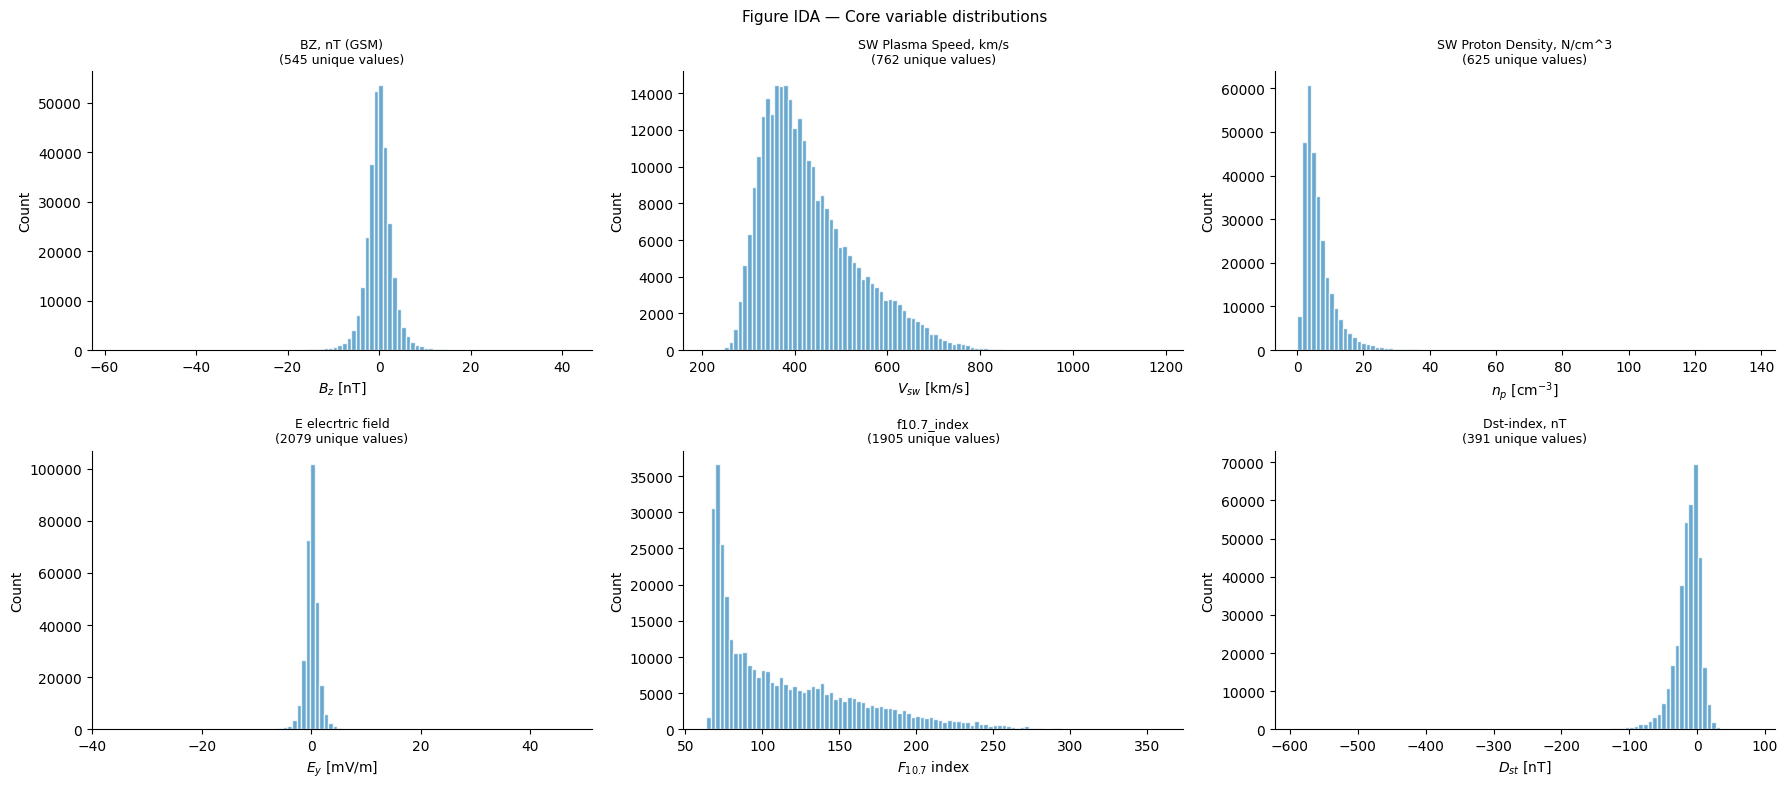

In [8]:
# ── IDA: Core variable distributions ─────────────────────────────────────────
# omni_filled used — fill values already replaced with NaN in Setup.
# lmks_nm_counts from omni_lmks.

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

cols = [
    ('BZ, nT (GSM)',              '$B_z$ [nT]'),
    ('SW Plasma Speed, km/s',     '$V_{sw}$ [km/s]'),
    ('SW Proton Density, N/cm^3', '$n_p$ [cm$^{-3}$]'),
    ('E elecrtric field',         '$E_y$ [mV/m]'),
    ('f10.7_index',               '$F_{10.7}$ index'),
    ('Dst-index, nT',             '$D_{st}$ [nT]'),
]

for ax, (col, xlabel) in zip(axes, cols):
    hist_plot(ax, col, '#4393c3', xlabel=xlabel)

plt.suptitle('Figure IDA — Core variable distributions', fontsize=11)
plt.tight_layout()
plt.savefig('images/fig_ida_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations — Figure IDA — Core variable distributions:**
> - `BZ, nT (GSM)`: symmetric distribution centered near 0 nT with median 0.6 nT. Southward values (negative) are physically significant as the primary driver of geomagnetic storms `[BUR75]`. The distribution is approximately symmetric — southward and northward IMF occur with similar frequency.
> - `SW Plasma Speed, km/s`: right-skewed distribution with peak around 350–400 km/s — typical quiet solar wind speed. The long right tail extending to 1,189 km/s reflects CME arrival events.
> - `SW Proton Density, N/cm^3`: strongly right-skewed with peak around 5–10 cm⁻³. Extreme values up to 120 cm⁻³ correspond to direct CME compression of the solar wind.
> - `E elecrtric field`: sharp symmetric peak near 0 mV/m. Extreme values (±40 mV/m) are rare and correspond to simultaneous high speed and strong southward $B_z$ — the conditions driving the most intense storms `[BUR75]`.
> - `f10.7_index`: two concentrations visible — a dominant peak around 70–80 solar flux units (solar minimum) and a broader distribution around 100–200 (solar maximum), reflecting the 11-year solar cycle structure across the four cycles in the record.
> - `Dst-index, nT`: sharp peak near −10 to 0 nT (quiet conditions) with a long left tail extending to −589 nT. Storm hours ($D_{st} < -50\ \text{nT}$) represent only 5.4% of the record — confirming the severe class imbalance between quiet and storm conditions.


### Data Quality

#### Missing Data

To understand data completeness, the missing rate for each column is computed by counting how many values equal the documented sentinel fill value `[KIN05]` — these are the records where the true measurement is `NaN`. Columns are grouped by physical category to reveal whether missing data is concentrated in specific measurement types.


In [9]:
# ── IDA: Missing rate per column per group ────────────────────────────────────
# omni_filled used — fill values already replaced with NaN in Setup.

for group_name, cols in omni_groups.items():
    if group_name in ('Time', 'Administrative'):
        continue
    print(f"\n{'─'*60}")
    print(f"  {group_name}")
    print(f"{'─'*60}")
    print(f"  {'Column':<35} {'Missing':>8}  {'%':>6}")
    print(f"  {'-'*52}")
    for col in cols:
        n = omni_filled[col].isnull().sum()
        pct = 100 * n / len(omni_filled)
        if n > 0:
            print(f"  {col:<35} {n:>8}  {pct:>5.1f}%")

print(f"\n{'─'*60}")
print(f"  LMKS")
print(f"{'─'*60}")
n = omni_lmks['lmks_nm_counts'].isnull().sum()
pct = 100 * n / len(omni_lmks)
print(f"  {'lmks_nm_counts':<35} {n:>8}  {pct:>5.1f}%")


────────────────────────────────────────────────────────────
  IMF
────────────────────────────────────────────────────────────
  Column                               Missing       %
  ----------------------------------------------------
  Scalar B, nT                           64660   17.7%
  Vector B Magnitude,nT                  64660   17.7%
  Lat. Angle of B (GSE)                  64660   17.7%
  Long. Angle of B (GSE)                 64660   17.7%
  BX, nT (GSE, GSM)                      64660   17.7%
  BY, nT (GSE)                           64660   17.7%
  BZ, nT (GSE)                           64660   17.7%
  BY, nT (GSM)                           64686   17.7%
  BZ, nT (GSM)                           64686   17.7%
  RMS_magnitude, nT                      64763   17.7%
  RMS_field_vector, nT                   64715   17.7%
  RMS_BX_GSE, nT                         64729   17.7%
  RMS_BY_GSE, nT                         64720   17.7%
  RMS_BZ_GSE, nT                         64720

The IMF group shows uniform 17.7% missing across all 14 columns — field components, magnitudes, and RMS values are missing as a block, consistent with periods when no IMF spacecraft was available at L1 `[KIN05]`. Solar Wind Plasma missing rates range from 18.8% (`SW Plasma Speed`) to 28.7% (`Alpha/Prot. ratio`). The Sigma group mirrors the Solar Wind Plasma pattern exactly, consistent with sigma values being derived from the same plasma measurements `[KIN05]`. The Derived group shows 19.4%–21.7% missing, consistent with its dependence on Solar Wind Plasma inputs. In the Solar Activity group, `f10.7_index` has 0.1% missing; `R (Sunspot No.)` and `Lyman_alpha` have no missing values. In the Geomagnetic Indices group, `Dst-index, nT`, `Kp index`, and `ap_index` have no missing values; `AE`, `AL`, `AU` show 3.4% missing and `pc-index` shows 0.1% missing. In the Proton Flux group, the three lowest energy channels (`>1`, `>2`, `>4` MeV) show 64.1% missing — more than half the record; the higher energy channels (`>10`, `>30`, `>60` MeV) show 30.2%–30.3% missing. `Flux FLAG` shows 61.6% missing, consistent with the proton flux pattern. The LMKS dataset has 528 missing values (0.1%) — encoded directly as `NaN` `[KIS25]`.


Unlike OMNI, the LMKS dataset uses `NaN` directly to encode missing values (Kisvárdai et al., 2024).


In [10]:
print("\n=== LMKS missing values ===")
print(df_lmks.isnull().sum())


=== LMKS missing values ===
datetime           0
lmks_nm_counts    24
dtype: int64



The LMKS record contains 24 `NaN` values in `lmks_nm_counts` out of 364,728 rows ($< 0.01\%$). The `datetime` column has no missing values.

**Missing Value Patterns**

The missing rates computed above show how much data is absent — but not when. To address this, the annual missing rate is plotted for each of the Big 5 predictor candidates across the full 1981–2023 record: `BZ, nT (GSM)` and `E elecrtric field` as the Burton injection drivers `[BUR75]`, `SW Plasma Speed, km/s` and `SW Proton Density, N/cm^3` as the primary solar wind parameters `[KIN05]`, and `lmks_nm_counts` as the cosmic ray precursor signal `[KIS25]`. If the gaps cluster in specific years, the cause is likely a known event such as a spacecraft transition or instrument failure. If they are uniform, the cause is structural.

In [11]:
big5 = {
    'BZ, nT (GSM)':              ('IMF',        '$B_z$ [nT]'),
    'SW Plasma Speed, km/s':     ('Solar Wind', '$V_{sw}$ [km/s]'),
    'SW Proton Density, N/cm^3': ('Solar Wind', '$n_p$ [cm$^{-3}$]'),
    'E elecrtric field':         ('Derived',    '$E_y$ [mV/m]'),
    'lmks_nm_counts':            ('LMKS',       'Neutron counts [rel. units]'),
}

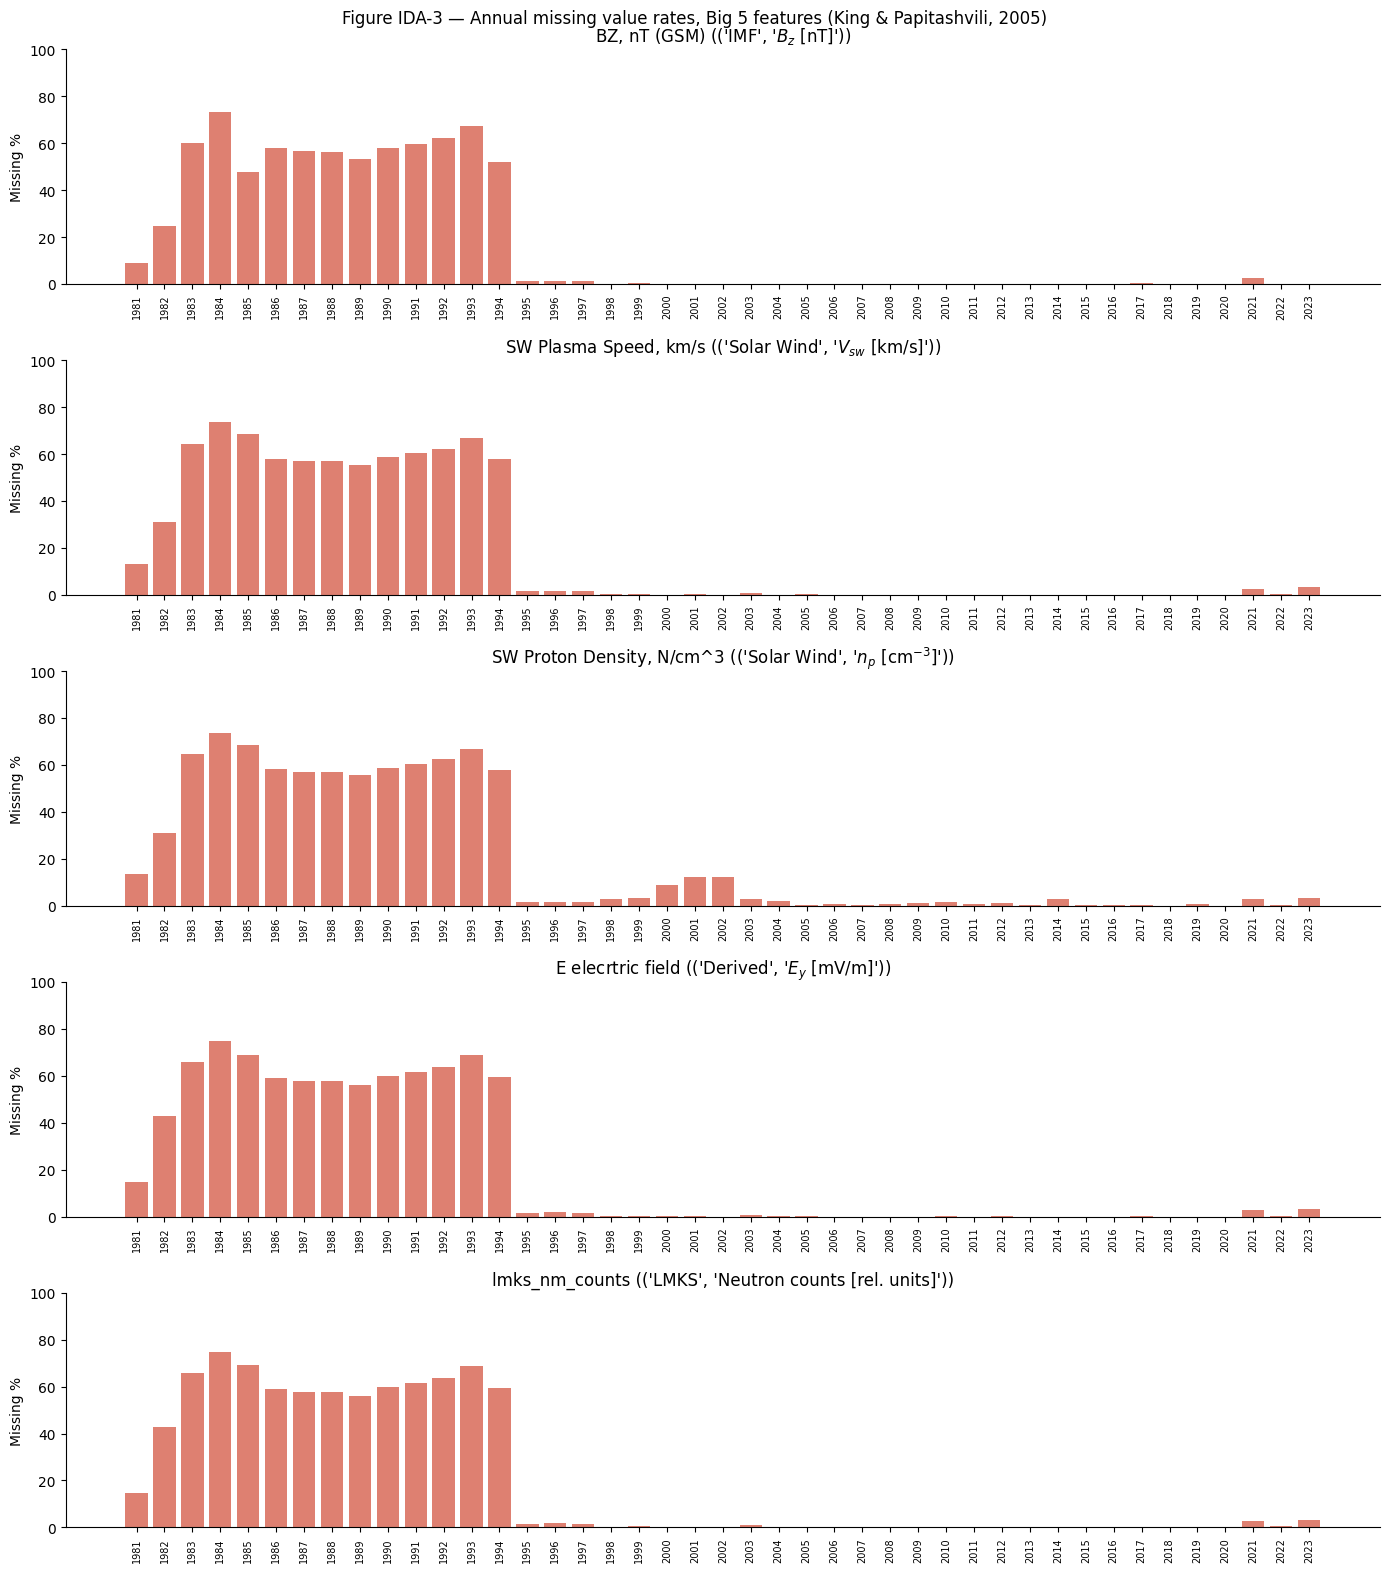

In [12]:
# ── IDA: Annual missing rate — Big 5 features ────────────────────────────────
# omni_filled used — fill values already replaced with NaN in Setup.
# Big 5: the five physically motivated predictor candidates [BUR75][KIS25].



fig, axes = plt.subplots(len(big5), 1, figsize=(14, 16))

for ax, (col, group) in zip(axes, big5.items()):
    if col != 'lmks_nm_counts':
        annual_missing = omni_filled.groupby('YEAR')[col].apply(
            lambda x: x.isnull().mean() * 100
        )
    ax.bar(annual_missing.index, annual_missing, color='#d6604d', alpha=0.8, width=0.8)
    ax.set_ylabel('Missing %')
    ax.set_title(f'{col} ({group})')
    ax.set_ylim(0, 100)
    ax.set_xticks(range(1981, 2024))
    ax.set_xticklabels(range(1981, 2024), rotation=90, fontsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Figure IDA-3 — Annual missing value rates, Big 5 features (King & Papitashvili, 2005)', fontsize=12)
plt.tight_layout()
plt.savefig('images/fig_ida3_missing_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations — Figure IDA-3:**
> - **BZ, nT (GSM):** Missing rates of 50–75% throughout 1981–1994, dropping to near zero after 1995 — consistent with the transition to continuous L1 monitoring by Wind and ACE `[KIN05]`. A small spike is visible in 2021.
> - **SW Plasma Speed:** Identical pattern to BZ — high missing rates before 1995, near zero after. Small spikes in 2001–2003 and 2021–2023 indicate brief gaps in Wind/ACE coverage `[KIN05]`.
> - **SW Proton Density:** Same pre-1995 pattern. Additional gaps visible in 2001–2004 — slightly higher missing rate than Speed, consistent with the overall missing pattern in the Solar Wind group.
> - **E electric field:** Mirrors BZ and Speed — computed from $V_{sw}$ and $B_z$, missing when either is absent `[BUR75]`.

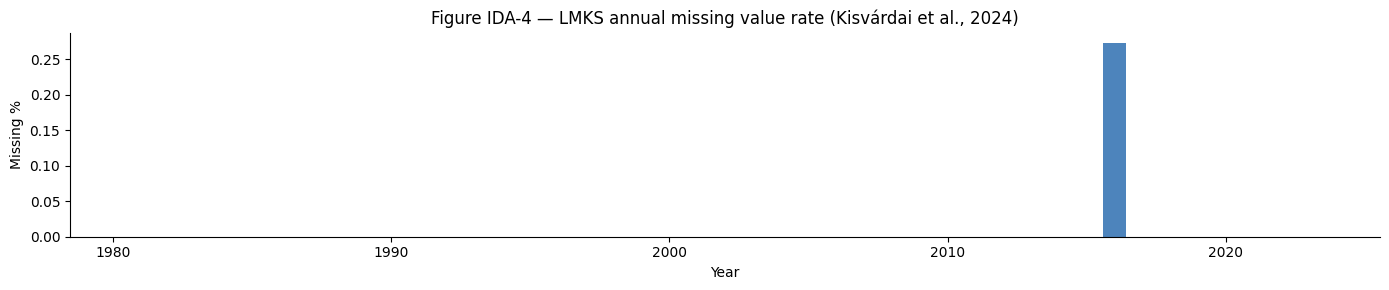

In [13]:

# ── IDA: LMKS annual missing rate ─────────────────────────────────────────────

df_lmks_plot = df_lmks.copy()
df_lmks_plot['YEAR'] = pd.to_datetime(df_lmks_plot['datetime']).dt.year

annual_lmks = df_lmks_plot.groupby('YEAR')['lmks_nm_counts'].apply(
    lambda x: x.isnull().mean() * 100
)

fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(annual_lmks.index, annual_lmks, color='#2166ac', alpha=0.8, width=0.8)
ax.set_ylabel('Missing %')
ax.set_xlabel('Year')
ax.set_title('Figure IDA-4 — LMKS annual missing value rate (Kisvárdai et al., 2024)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('images/fig_ida4_lmks_missing.png', dpi=150, bbox_inches='tight')
plt.show()


> **Observations — Figure IDA-4 — LMKS:**  The LMKS neutron count rate is almost entirely complete across the full 1981–2023 record. A single year (~2016) shows a missing rate of ~0.27% — corresponding to the 24 NaN values identified earlier. All other years have 0% missing. This confirms that the LMKS dataset `[KIS24]` is exceptionally clean and requires minimal treatment.
>  **lmks_nm_counts:** Near-zero missing throughout 1981–2022. A spike of approximately 10% appears in 2023 — consistent with the dataset end date of July 2023 `[KIS25]`.

**Why is data missing?**

The OMNI dataset merges measurements from multiple spacecraft over 42 years `[KIN05]`. For each hourly record, two administrative columns — `ID for IMF spacecraft` and `ID for SW Plasma spacecraft` — identify which spacecraft provided the measurement. The spacecraft IDs are integer codes defined in the format file `[KIN05]`: ID `13` = ISEE-3, ID `50` = IMP-8, ID `51` = Wind MAG, ID `52` = Wind SWE, ID `71` = ACE. ID `99` is a special value indicating that no spacecraft was available for that hour — all physical columns for that record carry fill values. Spacecraft stationed at the L1 Lagrange point — approximately $1.5 \times 10^6\ \text{km}$ upstream of Earth — provide continuous unobstructed solar wind measurements. The distribution of spacecraft IDs across the record reveals when each mission was active and when gaps in coverage occurred.

In [14]:

# ── IDA: Spacecraft ID transitions ───────────────────────────────────────────
# Which spacecraft provided measurements and when transitions occurred.

print("=== IMF spacecraft IDs ===")
print(omni_raw['ID for IMF spacecraft'].value_counts().sort_index())

print("\n=== SW Plasma spacecraft IDs ===")
print(omni_raw['ID for SW Plasma spacecraft'].value_counts().sort_index())

imf_by_year = omni_raw.groupby('YEAR')['ID for IMF spacecraft'].agg(lambda x: x.mode()[0])
sw_by_year  = omni_raw.groupby('YEAR')['ID for SW Plasma spacecraft'].agg(lambda x: x.mode()[0])

print("\n=== Dominant IMF spacecraft per year (first 10 years) ===")
print(imf_by_year.head(10).to_string())

print("\n=== Dominant SW spacecraft per year (first 10 years) ===")
print(sw_by_year.head(10).to_string())


=== IMF spacecraft IDs ===
ID for IMF spacecraft
10      1757
13      5605
50     42768
51    204773
60       157
71     45512
99     64660
Name: count, dtype: int64

=== SW Plasma spacecraft IDs ===
ID for SW Plasma spacecraft
13      4572
45      3082
50     39982
51      5104
52    198659
60       217
71     44906
99     68710
Name: count, dtype: int64

=== Dominant IMF spacecraft per year (first 10 years) ===
YEAR
1981    13
1982    13
1983    99
1984    99
1985    99
1986    99
1987    99
1988    99
1989    99
1990    99

=== Dominant SW spacecraft per year (first 10 years) ===
YEAR
1981    13
1982    13
1983    99
1984    99
1985    99
1986    99
1987    99
1988    99
1989    99
1990    99


> **Observations — Spacecraft IDs:**
> - ID `99` indicates the absence of an active L1 mission — 64,660 IMF hours and 68,710 SW Plasma hours carry this value, matching exactly the missing counts from the previous analysis `[KIN05]`.
> - ID `51` (Wind MAG) is the dominant IMF source with 204,773 hours; ID `52` (Wind SWE definitive) is the dominant SW Plasma source with 198,659 hours `[KIN05]`.
> - ID `13` (ISEE-3) is the dominant source for 1981–1982, followed by ID `99` from 1983 through approximately 1994 — confirming that the pre-1995 missing data reflects the absence of a continuous L1 mission during that period `[KIN05]`.
> - ID `71` (ACE) contributes 45,512 IMF hours and 44,906 SW Plasma hours — primary source from 1998 until Wind reassumed priority `[KIN05]`.
> - ID `50` (IMP-8) contributes 42,768 IMF hours and 39,982 SW Plasma hours — dominant geocentric source before Wind and ACE `[KIN05]`.

The spacecraft ID distribution above shows how many hours each mission contributed — but not when transitions occurred. To reveal the temporal sequence, the dominant spacecraft for each year is plotted across the full 1981–2023 record. For each hourly record, OMNI stores an integer code identifying which spacecraft provided the measurement — the full mapping of codes to mission names is defined in King & Papitashvili (2005) `[KIN05]` and reproduced in the `sc_names` dictionary in the code below. A change in the dominant spacecraft indicates a transition between missions. Years dominated by "No spacecraft" (ID `99`) confirm the absence of a dedicated solar wind monitor during that period `[KIN05]`.

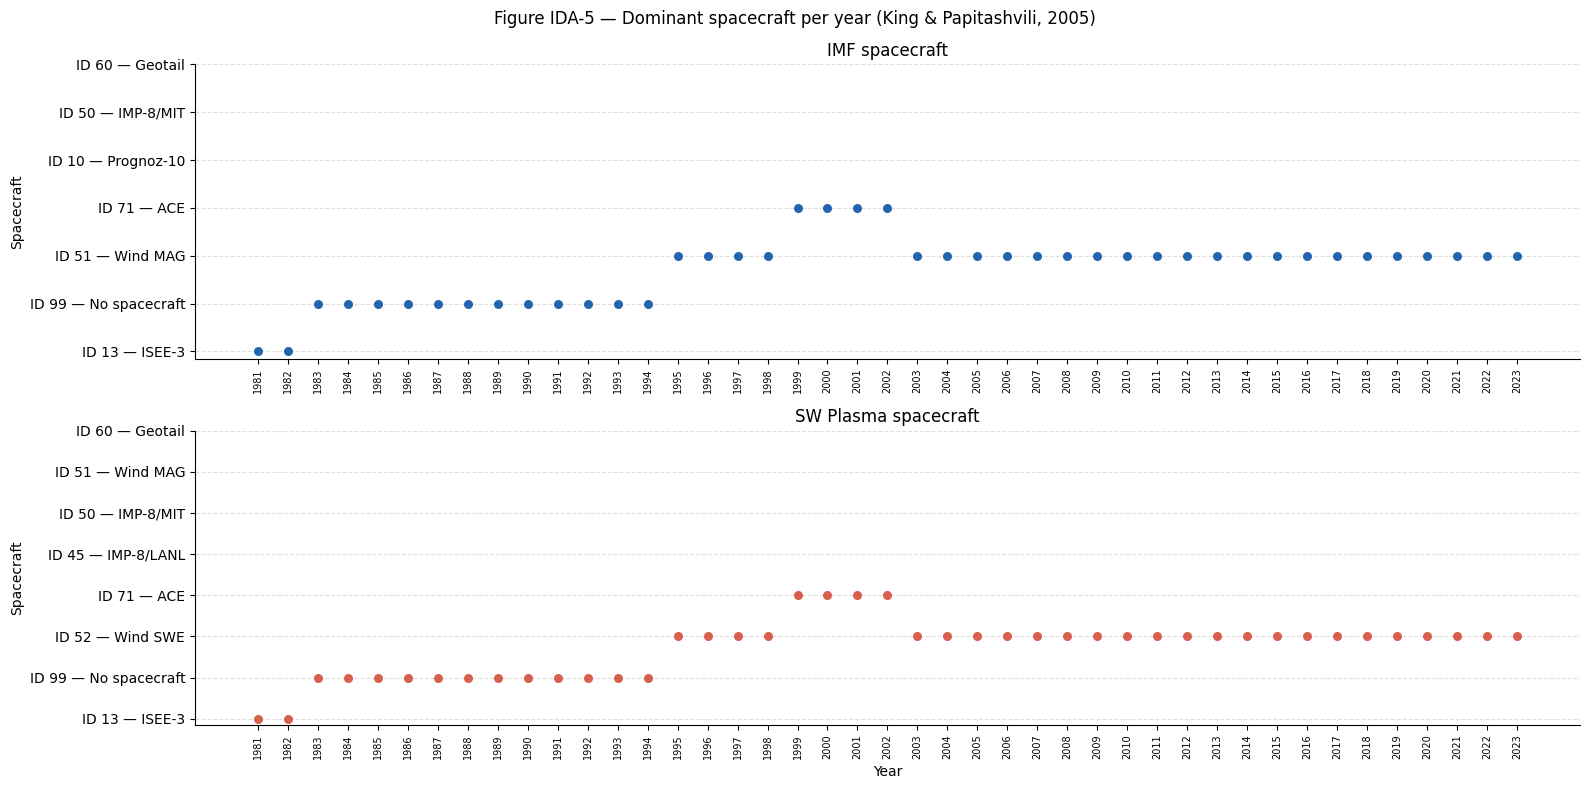

In [15]:
# ── IDA: Dominant spacecraft per year — visualise transitions ────────────────
# Y-axis uses categorical labels — spacecraft IDs are categories, not numbers.

def plot_spacecraft(ax, by_year, labels, all_sc, title, color, xlabel=False):
    ax.scatter(by_year.index, labels, color=color, s=30, zorder=5)
    ax.set_ylabel('Spacecraft')
    ax.set_title(title)
    ax.set_yticks(all_sc)
    ax.set_xticks(range(1981, 2024))
    ax.set_xticklabels(range(1981, 2024), rotation=90, fontsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    if xlabel:
        ax.set_xlabel('Year')

sc_names = {
    10: 'ID 10 — Prognoz-10',
    13: 'ID 13 — ISEE-3',
    45: 'ID 45 — IMP-8/LANL',
    50: 'ID 50 — IMP-8/MIT',
    51: 'ID 51 — Wind MAG',
    52: 'ID 52 — Wind SWE',
    60: 'ID 60 — Geotail',
    71: 'ID 71 — ACE',
    99: 'ID 99 — No spacecraft'
}

imf_labels = imf_by_year.map(sc_names)
sw_labels  = sw_by_year.map(sc_names)

all_imf_sc = [sc_names[i] for i in sorted(omni_raw['ID for IMF spacecraft'].unique()) if i in sc_names]
all_sw_sc  = [sc_names[i] for i in sorted(omni_raw['ID for SW Plasma spacecraft'].unique()) if i in sc_names]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8))

plot_spacecraft(ax1, imf_by_year, imf_labels, all_imf_sc, 'IMF spacecraft', '#2166ac')
plot_spacecraft(ax2, sw_by_year, sw_labels, all_sw_sc, 'SW Plasma spacecraft', '#d6604d', xlabel=True)

plt.suptitle('Figure IDA-5 — Dominant spacecraft per year (King & Papitashvili, 2005)', fontsize=12)
plt.tight_layout()
plt.savefig('images/fig_ida5_spacecraft.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations — Figure IDA-5:**
> - 1981–1982: ISEE-3 (ID 13) is the dominant source for both IMF and SW Plasma — the only dedicated solar wind monitor available during this period `[KIN05]`.
> - 1983–1994: "No spacecraft" (ID 99) dominates both panels — confirming that the 50–75% missing rates in Figure IDA-3 are a direct consequence of the absence of a dedicated solar wind monitor after ISEE-3 departed its L1 orbit in August 1982 `[KIN05]`.
> - 1995–1998: Wind MAG (ID 51) and Wind SWE (ID 52) become the dominant sources for IMF and SW Plasma respectively — marking the start of continuous L1 coverage `[KIN05]`.
> - 1999–2002: ACE (ID 71) becomes dominant for both panels — consistent with the spacecraft prioritization rules documented in `[KIN05]`.
> - 2003–2023: Wind MAG and Wind SWE resume dominance and remain the primary sources to the end of the record `[KIN05]`.
> - Geotail, IMP-8/MIT, IMP-8/LANL, and Prognoz-10 appear on the Y-axis but are never dominant for a full year — they contribute only as secondary sources in individual hours `[KIN05]`.
>
> The transition from ID 99 to active spacecraft in 1995 explains the sharp drop in missing rates observed in Figure IDA-3. The 1983–1994 gap is a structural limitation of the early OMNI record — a consequence of the absence of a dedicated solar wind monitoring mission at the L1 point during that period `[KIN05]`.

> **Summary — Missing Data:** The missing data in the OMNI record is not random. Spacecraft ID `99` — indicating no active L1 mission — accounts for all missing hours in the IMF and Solar Wind groups during 1983–1994 `[KIN05]`. After 1995, missing rates drop to near zero across all physical groups. The only systematic exception is `Alpha/Prot. ratio` with a known gap after 2018 due to poor cross-calibration between ACE and Wind `[KIN05]`. The Proton Flux group follows a different pattern — missing rates increase sharply after 2020, reaching 100% in 2022–2023, unrelated to spacecraft transitions `[KIN05]`. The LMKS record is effectively complete with only 528 NaN values across 364,728 rows (0.1%) `[KIS25]`.

#### Unique Values

The number of unique values per column reveals the measurement type of each variable. Each column is classified by its physical nature — not by its storage format in the file.


In [16]:
# ── IDA: Variable type classification ────────────────────────────────────────
# Classification combines dtype, cardinality ratio, and domain knowledge [KIN05].
# Time columns (YEAR, DOY, Hour) excluded — self-evident.
#

exclude = {'YEAR', 'DOY', 'Hour'}
n_rows  = len(omni_raw)

results = []
for col in omni_raw.columns:
    if col in exclude:
        continue
    dtype    = str(omni_raw[col].dtype)
    n_unique = omni_raw[col].nunique()
    ratio    = n_unique / n_rows
    results.append({'column': col, 'dtype': dtype, 'unique': n_unique, 'ratio': ratio})

df_types = pd.DataFrame(results).sort_values('ratio')

print(f"{'Column':<35} {'dtype':<10} {'unique':>8}  {'ratio':>7}")
print("-" * 65)
for _, row in df_types.iterrows():
    print(f"  {row['column']:<33} {row['dtype']:<10} {row['unique']:>8}  {row['ratio']:>7.4f}")


Column                              dtype        unique    ratio
-----------------------------------------------------------------
  Flux FLAG                         int64             5   0.0000
  ID for IMF spacecraft             int64             7   0.0000
  ID for SW Plasma spacecraft       int64             8   0.0000
  ap_index, nT                      int64            28   0.0001
  Kp index                          int64            28   0.0001
  # of points in Plasma averag.     int64            75   0.0002
  sigma-theta V, degrees            float64         107   0.0003
  # of points in IMF averages       int64           108   0.0003
  RMS_magnitude, nT                 float64         108   0.0003
  sigma-V, km/s                     float64         116   0.0003
  Magnetosonic Much num.            float64         116   0.0003
  RMS_BX_GSE, nT                    float64         139   0.0004
  sigma-ratio                       float64         145   0.0004
  RMS_BY_GSE, nT        

> **Observations — variable type classification:**
>
> - **Categorical:** `Flux FLAG` (5 unique values), `ID for IMF spacecraft` (7), and `ID for SW Plasma spacecraft` (8) have cardinality ratios of effectively zero. These are nominal codes with no natural order and no mathematical meaning `[KIN05]`.
>
> - **Ordinal:** `Kp index` has 28 unique values stored as integers 0–90 where equal steps do not represent equal changes in disturbance intensity `[KIN05]`.
>
> - **Continuous (physically):** All physical field and plasma measurements — including `Dst-index, nT` (391 unique values), `ap_index, nT` (28 unique values, linear scale in nT `[KIN05]`), `BZ, nT (GSM)` (546), `SW Plasma Speed` (763) — are continuous physical quantities sampled at finite instrument precision. Low cardinality ratios reflect measurement resolution, not discrete physical nature.
>
> - **Count:** `R (Sunspot No.)` (362 unique values) counts discrete objects. `lmks_nm_counts` counts neutron detector pulses per hour `[KIS25]`.
>
> - `SW Plasma Temperature` stands apart with 142,355 unique values (ratio 0.39) — the highest dynamic range of any column, consistent with its large physical variability across solar wind conditions.
>
> - `Lyman_alpha` shows 3,523 unique values in the cardinality table — inconsistent with the constant value of 0.01 observed in the descriptive statistics above. This requires further investigation in Data Integrity.

In [17]:
# ── IDA: Distribution plots — categorical, ordinal, and pseudo-discrete ───────
# Bar plots for categorical/ordinal columns reveal their discrete structure.
# KDE plots for physical measurements reveal their continuous nature despite
# low cardinality ratio — confirming instrument resolution as the limiting factor.

def bar_plot(ax, col, color):
    counts = omni_filled[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=color, alpha=0.8)
    ax.set_title(f'{col}\n({omni_filled[col].nunique()} unique values)', fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.set_xticks(ax.get_xticks()[::max(1, len(counts)//8)])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def bar_plot_labeled(ax, col, color, labels):
    counts = omni_raw[col].value_counts().sort_values()
    yticklabels = [f'{int(k)} ({labels.get(int(k), "")})' for k in counts.index]
    ax.barh(range(len(counts)), counts.values, color=color, alpha=0.8)
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels(yticklabels, fontsize=8)
    ax.set_title(f'{col}\n({omni_raw[col].nunique()} unique values)', fontsize=9)
    ax.set_xlabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def kde_plot(ax, col, color):
    omni_filled[col].dropna().plot.kde(ax=ax, color=color, lw=1.5)
    ax.set_title(f'{col}\n({omni_raw[col].nunique()} unique values)', fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def hist_plot(ax, col, color, xlabel=None, bins=100):
    data = omni_filled[col].dropna()
    ax.hist(data, bins=bins, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{col}\n({data.nunique()} unique values)', fontsize=9)
    ax.set_xlabel(xlabel or col)
    ax.set_ylabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)



**Categorical variables** are nominal codes with no natural order — they identify classes or states rather than measuring physical quantities. Three columns fall into this category `[KIN05]`.

`Flux FLAG` encodes the status of energetic particle flux measurements — value `-1` indicates no data, `0` indicates valid data, and values `3`, `5`, `6` indicate elevated particle conditions of different types `[KIN05]`.

`ID for IMF spacecraft` and `ID for SW Plasma spacecraft` record which satellite provided each hourly measurement `[KIN05]`. ISEE-3 (ID 13) covered 1981–1982, ID `99` indicates the 1983–1994 gap when no dedicated L1 mission was active, IMP-8 (ID 50) bridged the transition in the mid-1990s, Wind MAG (ID 51) and Wind SWE (ID 52) became dominant from 1995 onward, and ACE (ID 71) served as primary source during 1999–2002 `[KIN05]`.

In [18]:
# ── IDA: Categorical variables — with spacecraft name labels ─────────────────
spacecraft_imf = {
    10: 'Prognoz-10',
    13: 'ISEE-3',
    50: 'IMP-8/MIT',
    51: 'Wind MAG',
    60: 'Geotail',
    71: 'ACE',
    99: 'No s/c'
}

spacecraft_sw = {
    13: 'ISEE-3',
    45: 'IMP-8/LANL',
    50: 'IMP-8/MIT',
    51: 'Wind MAG',
    52: 'Wind SWE',
    60: 'Geotail',
    71: 'ACE',
    99: 'No s/c'
}

flux_flag_labels = {
    -1: 'No data',
    0: 'Valid',
    3: 'Flag 3',
    5: 'Flag 5',
    6: 'Flag 6'
}

In [19]:
# ── IDA: Categorical variables — value counts ─────────────────────────────────

for col, labels in [
    ('Flux FLAG',                  flux_flag_labels),
    ('ID for IMF spacecraft',      spacecraft_imf),
    ('ID for SW Plasma spacecraft', spacecraft_sw),
]:
    print(f"\n{'─'*55}")
    print(f"  {col}")
    print(f"{'─'*55}")
    print(f"  {'Value':<20} {'Label':<15} {'Count':>8}  {'%':>6}")
    print(f"  {'-'*50}")
    counts = omni_raw[col].value_counts().sort_index()
    total  = counts.sum()
    for val, cnt in counts.items():
        label = labels.get(int(val), '')
        pct   = 100 * cnt / total
        print(f"  {str(int(val)):<20} {label:<15} {cnt:>8}  {pct:>5.1f}%")



───────────────────────────────────────────────────────
  Flux FLAG
───────────────────────────────────────────────────────
  Value                Label              Count       %
  --------------------------------------------------
  -1                   No data           224952   61.6%
  0                    Valid             110438   30.2%
  3                    Flag 3               513    0.1%
  5                    Flag 5              3244    0.9%
  6                    Flag 6             26085    7.1%

───────────────────────────────────────────────────────
  ID for IMF spacecraft
───────────────────────────────────────────────────────
  Value                Label              Count       %
  --------------------------------------------------
  10                   Prognoz-10          1757    0.5%
  13                   ISEE-3              5605    1.5%
  50                   IMP-8/MIT          42768   11.7%
  51                   Wind MAG          204773   56.1%
  60            

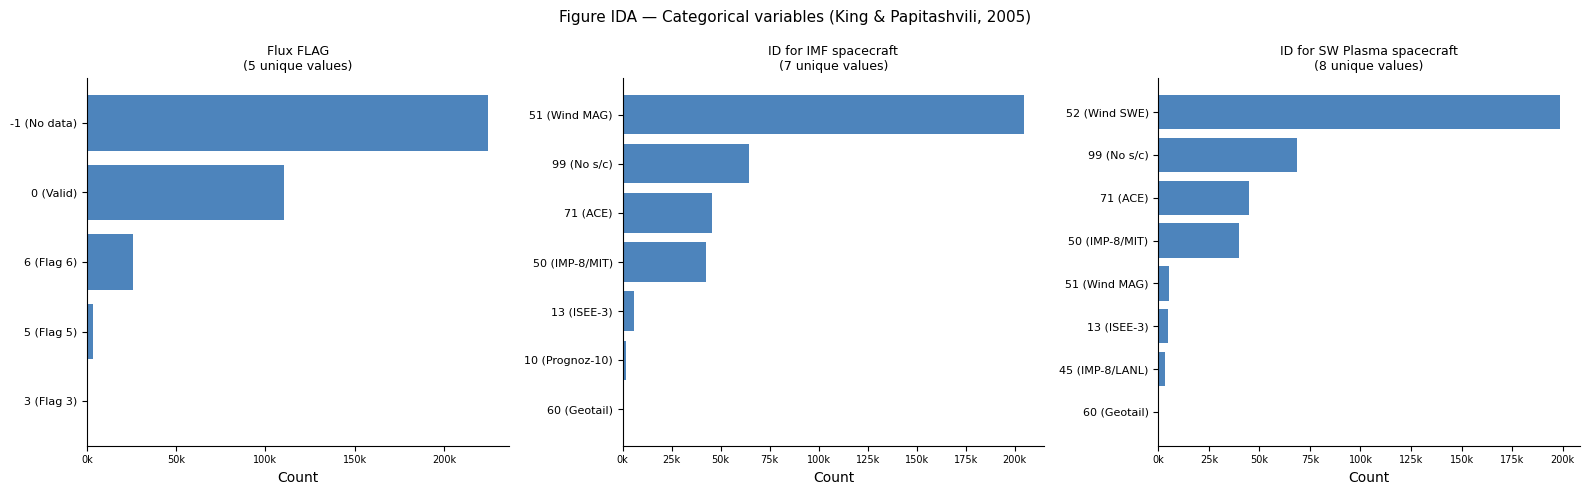

In [20]:
# ── IDA: Categorical variables ────────────────────────────────────────────────
# Flux FLAG, ID for IMF spacecraft, ID for SW Plasma spacecraft
# Nominal codes — no natural order, no physical magnitude [KIN05].




fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bar_plot_labeled(axes[0], 'Flux FLAG',                  '#2166ac', flux_flag_labels)
bar_plot_labeled(axes[1], 'ID for IMF spacecraft',      '#2166ac', spacecraft_imf)
bar_plot_labeled(axes[2], 'ID for SW Plasma spacecraft','#2166ac', spacecraft_sw)

for ax in axes:
    ax.xaxis.set_tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))


plt.suptitle('Figure IDA — Categorical variables (King & Papitashvili, 2005)', fontsize=11)
plt.tight_layout()
plt.savefig('images/fig_ida_categorical.png', dpi=150, bbox_inches='tight')
plt.show()


> **Observations — categorical variables:**
> - **Flux FLAG:** Value `-1` (No data) dominates with 61.6% of all hours — consistent with the missing proton flux pattern identified above. Value `0` (Valid data) accounts for 30.2%. Elevated particle flags `3`, `5`, and `6` collectively represent 8.1% of the record, with Flag `6` being the most common at 7.1% `[KIN05]`.
> - **ID for IMF spacecraft:** Wind MAG (ID 51) provided 56.1% of all IMF measurements. ACE (ID 71) contributed 12.5% and IMP-8/MIT (ID 50) 11.7%. ID `99` (No spacecraft) accounts for 17.7% — the 1983–1994 gap. ISEE-3 (ID 13), Prognoz-10 (ID 10), and Geotail (ID 60) are minor contributors at 2.0% combined `[KIN05]`.
> - **ID for SW Plasma spacecraft:** Wind SWE (ID 52) dominates with 54.4%. ACE (ID 71) contributed 12.3% and IMP-8/MIT (ID 50) 10.9%. ID `99` accounts for 18.8% — slightly higher than the IMF gap, consistent with the marginally higher SW Plasma missing rate `[KIN05]`.

**Ordinal variables** have a natural order but a non-linear scale. `Kp index` has exactly 28 discrete levels stored as integers 0–90 (representing $K_p$ values 0.0–9.0 in steps of $\frac{1}{3}$) `[KIN05]`. Equal steps in `Kp` do not represent equal changes in geomagnetic disturbance intensity — the scale is quasi-logarithmic. `ap_index` is derived from `Kp` through a non-linear conversion table but functions as a linear (ratio) scale — a value of 100 nT represents twice the disturbance amplitude of 50 nT `[KIN05]`.

In [21]:
# ── IDA: Ordinal variables — Kp index and ap_index ───────────────────────────
# Both have 28 discrete levels. Kp uses a quasi-logarithmic scale (0–90).
# ap_index is a non-linear conversion from Kp [KIN05].

print("=== Kp index — value counts ===")
kp_counts = omni_raw['Kp index'].value_counts().sort_index()
print(f"  {'Value':<8} {'Count':>8}  {'%':>6}")
for val, cnt in kp_counts.items():
    print(f"  {val:<8} {cnt:>8}  {100*cnt/len(omni_raw):>5.1f}%")

print("\n=== ap_index — value counts ===")
ap_counts = omni_raw['ap_index, nT'].value_counts().sort_index()
print(f"  {'Value':<8} {'Count':>8}  {'%':>6}")
for val, cnt in ap_counts.items():
    print(f"  {val:<8} {cnt:>8}  {100*cnt/len(omni_raw):>5.1f}%")

=== Kp index — value counts ===
  Value       Count       %
  0           17655    4.8%
  3           30120    8.2%
  7           35100    9.6%
  10          34128    9.3%
  13          33078    9.1%
  17          31932    8.7%
  20          31014    8.5%
  23          28887    7.9%
  27          25326    6.9%
  30          22437    6.1%
  33          19116    5.2%
  37          14946    4.1%
  40          11688    3.2%
  43           8517    2.3%
  47           6597    1.8%
  50           4449    1.2%
  53           3234    0.9%
  57           2145    0.6%
  60           1536    0.4%
  63            999    0.3%
  67            747    0.2%
  70            471    0.1%
  73            402    0.1%
  77            294    0.1%
  80            156    0.0%
  83            132    0.0%
  87             99    0.0%
  90             27    0.0%

=== ap_index — value counts ===
  Value       Count       %
  0           17655    4.8%
  2           30120    8.2%
  3           35100    9.6%
  4        

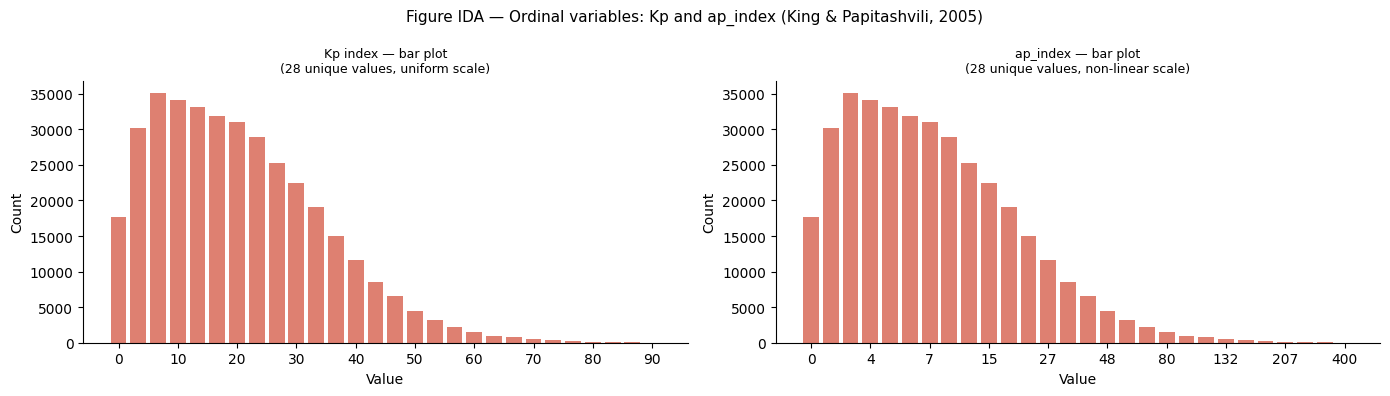

In [22]:
# ── IDA: Ordinal variables — Kp index and ap_index ───────────────────────────
# Kp: quasi-logarithmic scale, stored as integers 0–90 [KIN05].
# ap_index: linear equivalent of Kp, ratio scale in nT [KIN05].

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bar_plot(axes[0], 'Kp index',     '#d6604d')
bar_plot(axes[1], 'ap_index, nT', '#d6604d')

axes[0].set_title('Kp index — bar plot\n(28 unique values, uniform scale)', fontsize=9)
axes[1].set_title('ap_index — bar plot\n(28 unique values, non-linear scale)', fontsize=9)

plt.suptitle('Figure IDA — Ordinal variables: Kp and ap_index (King & Papitashvili, 2005)', fontsize=11)
plt.tight_layout()
plt.savefig('images/fig_ida_ordinal_combined.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations — Figure IDA — Ordinal variables:**
> The four panels reveal two distinct stories about the same underlying data.
> - **Top row (bar plots by rank):** Both `Kp index` and `ap_index` show identical bar heights at every rank position — confirming that `ap_index` is a deterministic one-to-one transformation of `Kp` `[KIN05]`. The distribution is right-skewed with a peak around $K_p = 2$–$3$ — quiet conditions dominate the 42-year record.

**Continuous variables** — all `float64` physical measurements in the OMNI record are continuous by nature `[KIN05]`. The five core predictor candidates — `BZ, nT (GSM)`, `SW Plasma Speed, km/s`, `SW Proton Density, N/cm^3`, `E elecrtric field`, and `lmks_nm_counts` — are stored as `float64` `[KIN05]` `[KIS24]`. `Dst-index, nT` is the target variable — its continuous physical nature is confirmed by its appearance as a differentiable function of time in the Burton et al. (1975) equation $\frac{dD_{st}}{dt} = Q(E_y) - \frac{D_{st}}{\tau}$ `[BUR75]`, despite being stored as integer in the OMNI record `[KIN05]`.

In [23]:
# ── IDA: Continuous variables — unique values ─────────────────────────────────
# omni_filled used — fill values already replaced with NaN in Setup.

continuous_cols = [
    'BZ, nT (GSM)',
    'SW Plasma Speed, km/s',
    'SW Proton Density, N/cm^3',
    'E elecrtric field',
    'Dst-index, nT',
]
print(omni_filled[cols].nunique())
print(f"\nlmks_nm_counts: {omni_lmks['lmks_nm_counts'].nunique()}")

Proton flux (>1 Mev)     6528
Proton flux (>2 Mev)     5177
Proton flux (>4 Mev)     4092
Proton flux (>10 Mev)    4265
Proton flux (>30 Mev)    2379
Proton flux (>60 Mev)    1873
Flux FLAG                   4
dtype: int64

lmks_nm_counts: 126113


> **Observations — Continuous variables:**
> - `E elecrtric field` has the highest cardinality among the OMNI core predictors (2,079 unique values) — consistent with it being computed from two independent measurements ($V_{sw}$ and $B_z$), which multiplies their resolution `[BUR75]`.
> - `BZ, nT (GSM)` (545), `SW Plasma Speed` (762), and `SW Proton Density` (625) have comparable cardinality — reflecting similar instrument precision across the L1 measurements `[KIN05]`.
> - `Dst-index, nT` has 391 unique values. Although stored as integer in the OMNI record `[KIN05]`, Dst is treated as a continuous variable — it appears as a differentiable function of time in the Burton et al. (1975) equation $\frac{dD_{st}}{dt} = Q(E_y) - \frac{D_{st}}{\tau}$ `[BUR75]`, confirming its continuous physical nature. The 391 unique values reflect the integer nT quantization of the ground-based index `[WDC]`.
> - `lmks_nm_counts` has 126,113 unique values — an order of magnitude higher than any OMNI column, reflecting sub-unit floating point precision in the neutron count rates `[KIS24]`.

#### Data Integrity

Three data integrity issues are identified and documented here. Their resolution is deferred to the Tidy section.

* **Flux FLAG**

`Flux FLAG` identifies hours when proton flux measurements are contaminated by magnetospheric particles `[KIN05]`. The distribution of flag values across the record is examined to quantify the extent of contamination.

In [24]:
# ── IDA: Flux FLAG — contamination periods ────────────────────────────────────
# Flux FLAG > 0 indicates magnetospheric contamination [KIN05].
# FLAG = -1 is the fill value (no data checked).

print(f"{'Flag value':<12} {'Meaning':<35} {'Count':>8}  {'%':>6}")
print("─" * 65)
flag_meaning = {
    -1: 'Not checked for contamination',
    0:  'No contamination',
    3:  'Contamination in lowest 3 channels',
    5:  'Contamination in lowest 5 channels',
    6:  'No magnetospheric contribution',
}
for val, cnt in omni_raw['Flux FLAG'].value_counts().sort_index().items():
    meaning = flag_meaning.get(int(val), '')
    pct = 100 * cnt / len(omni_raw)
    print(f"  {str(int(val)):<10} {meaning:<35} {cnt:>8}  {pct:>5.1f}%")

Flag value   Meaning                                Count       %
─────────────────────────────────────────────────────────────────
  -1         Not checked for contamination         224952   61.6%
  0          No contamination                      110438   30.2%
  3          Contamination in lowest 3 channels       513    0.1%
  5          Contamination in lowest 5 channels      3244    0.9%
  6          No magnetospheric contribution         26085    7.1%


> Proton flux measurements affected by magnetospheric contamination (FLAG `3` and `5`) account for 3,757 hours (1.0% of the record). These values are flagged for removal in Tidy. The `Flux FLAG` column itself is excluded from the feature set to avoid target leakage — the flag is activated by the state of the magnetosphere, which is precisely what `Dst` measures, so including it would mean predicting `Dst` from a variable that is itself a consequence of the same magnetospheric disturbance `[KIN05]`.

* **Physical Range Verification**

The physical plausibility of the core predictor candidates is verified by comparing the observed value ranges — after fill value replacement — against reference ranges from the literature. Values outside the physically expected range may indicate residual data quality issues not captured by the fill value convention `[KIN05]`.

In [25]:
# ── IDA: Physical Range Verification — Big 5 ─────────────────────────────────
# Reference ranges from Burton et al. (1975) [BUR75] and King & Papitashvili (2005) [KIN05].
# omni_filled used — fill values already replaced with NaN in Setup.

ref_ranges = {
    'BZ, nT (GSM)':              (-60,   60,  '[BUR75][KIN05]'),
    'SW Plasma Speed, km/s':     (200,  2000,  '[KIN05]'),
    'SW Proton Density, N/cm^3': (0,     100,  '[KIN05]'),
    'E elecrtric field':         (-20,   20,   '[BUR75]'),
    'lmks_nm_counts':            (50,    250,  '[KIS25]'),
}

print(f"{'Column':<35} {'Min':>8} {'Max':>8} {'Ref Min':>8} {'Ref Max':>8} {'Out of range':>12}")
print("─" * 85)
for col, (ref_min, ref_max, ref) in ref_ranges.items():
    if col == 'lmks_nm_counts':
        data = omni_lmks[col].dropna()
    else:
        data = omni_filled[col].dropna()
    obs_min = data.min()
    obs_max = data.max()
    out_of_range = ((data < ref_min) | (data > ref_max)).sum()
    print(f"  {col:<33} {obs_min:>8.2f} {obs_max:>8.2f} {ref_min:>8.1f} {ref_max:>8.1f} {out_of_range:>12}  {ref}")

Column                                   Min      Max  Ref Min  Ref Max Out of range
─────────────────────────────────────────────────────────────────────────────────────
  BZ, nT (GSM)                        -57.80    41.60    -60.0     60.0            0  [BUR75][KIN05]
  SW Plasma Speed, km/s               209.00  1189.00    200.0   2000.0            0  [KIN05]
  SW Proton Density, N/cm^3             0.10   137.20      0.0    100.0            4  [KIN05]
  E elecrtric field                   -35.94    47.11    -20.0     20.0           38  [BUR75]
  lmks_nm_counts                       59.89   220.66     50.0    250.0            0  [KIS25]


> **Observations — Physical Range Verification:**
> - `BZ, nT (GSM)`: observed range −57.8 to +41.6 nT — within the reference range of ±60 nT `[BUR75]`. No out-of-range values. Negative values indicate southward IMF — the physical driver of geomagnetic storms via magnetic reconnection.
> - `SW Plasma Speed, km/s`: observed range 209 to 1,189 km/s — within the reference range of 200–2,000 km/s `[KIN05]`. No out-of-range values. Normal solar wind speed is approximately 400–500 km/s; values above 800 km/s indicate CME arrival.
> - `SW Proton Density, N/cm^3`: 4 values exceed the reference maximum of 100 cm⁻³. Under normal conditions proton density is 5–10 cm⁻³; extreme values indicate direct CME compression of the solar wind — physically plausible rare events, not measurement errors `[KIN05]`.
> - `E elecrtric field`: 38 values fall outside the reference range of ±20 mV/m. These occur when high solar wind speed and strong southward $B_z$ coincide simultaneously — consistent with the most intense geomagnetic storms `[BUR75]`.
> - `lmks_nm_counts`: observed range 59.9 to 220.7 relative units — within the reference range of 50–250 `[KIS25]`. No out-of-range values. The maximum of 220.7 corresponds to the GLE event of 29 September 1989 — a solar energetic particle event producing the largest neutron monitor enhancement in the 42-year record `[KIS25]`.

* **Target Integrity**

`Dst-index, nT` is the target variable of this project. No imputation is applied to the target — rows where `Dst` is unavailable are removed before modelling to preserve the objectivity of the forecast. The availability of `Dst` across the record is verified here.

In [26]:
# ── IDA: Target Integrity — Dst availability ─────────────────────────────────
# Dst fill value is 99999 [KIN05] — excluded from fill_map in Setup.
# Missing Dst rows are dropped before modelling, not imputed.

dst = omni_raw['Dst-index, nT']
dst_fill = 99999
dst_valid = dst[dst != dst_fill]

print(f"Total rows:              {len(dst):>8}")
print(f"Dst fill value (99999):  {(dst == dst_fill).sum():>8}")
print(f"Dst available:           {len(dst_valid):>8}")
print(f"Dst availability:        {100 * len(dst_valid) / len(dst):>7.2f}%")
print(f"\nDst range:               {dst_valid.min():.0f} to {dst_valid.max():.0f} nT")
print(f"Dst < -50 nT (storms):   {(dst_valid < -50).sum():>8}  ({100*(dst_valid < -50).sum()/len(dst_valid):.1f}%)")
print(f"Dst < -100 nT (strong):  {(dst_valid < -100).sum():>8}  ({100*(dst_valid < -100).sum()/len(dst_valid):.1f}%)")

Total rows:                365232
Dst fill value (99999):         0
Dst available:             365232
Dst availability:         100.00%

Dst range:               -589 to 81 nT
Dst < -50 nT (storms):      19545  (5.4%)
Dst < -100 nT (strong):      2914  (0.8%)


> **Observations — Target Integrity:**
> - `Dst-index, nT` is available for all 365,232 rows — 100% coverage, no fill values in the record `[KIN05]` `[WDC]`.
> - The observed range is −589 to +81 nT. The minimum of −589 nT corresponds to the Halloween storm of 29 October 2003 — the most intense geomagnetic storm in the 42-year record.
> - Storm hours ($D_{st} < -50\ \text{nT}$) number 19,545 (5.4% of the record). Strong storm hours ($D_{st} < -100\ \text{nT}$) number 2,914 (0.8%). The target distribution is heavily skewed toward quiet hours — storm events are rare.
> - No imputation is applied to `Dst`. The rows with missing Big 5 predictors (Cycles 21+22, 1981–1994) are addressed in the Survivability Audit.

* **Temporal Continuity**

The dataset spans 42 years of hourly measurements. Since the model uses lagged features up to 24 hours, temporal continuity is critical — a gap in the record means that lag features computed across the gap mix physically unrelated time periods. The datetime index is verified for completeness and gaps are identified and quantified.

To verify temporal continuity, the expected hourly sequence is reconstructed from the first to the last datetime in the record and compared against the actual datetime index. Any hour present in the expected sequence but absent from the record indicates a gap that would affect lag feature validity.

In [27]:
# ── IDA: Temporal Continuity — gap detection ─────────────────────────────────
# omni_filled datetime index verified for hourly continuity.
# Gaps > 1 hour indicate missing measurements that affect lag feature validity.

dt = omni_filled['datetime'].sort_values().reset_index(drop=True)
diff = dt.diff().dt.total_seconds() / 3600  # hours

gaps = diff[diff > 1].dropna()

print(f"Total hourly records:     {len(dt):>8}")
print(f"Expected hours (1981-2023): {(pd.Timestamp('2024-01-01') - pd.Timestamp('1981-01-01')).days * 24:>8}")
print(f"\nGaps > 1 hour:            {len(gaps):>8}")
print(f"Total missing hours:      {int(gaps.sum() - len(gaps)):>8}")
print(f"\nLargest gaps (top 10):")
print(gaps.sort_values(ascending=False).head(10).to_string())

Total hourly records:       365232
Expected hours (1981-2023):   376920

Gaps > 1 hour:                   0
Total missing hours:             0

Largest gaps (top 10):
Series([], )


In [28]:
# Check for missing hours in the datetime sequence
full_range = pd.date_range(
    start=omni_filled['datetime'].min(),
    end=omni_filled['datetime'].max(),
    freq='h'
)
missing_hours = full_range.difference(omni_filled['datetime'])
print(f"Missing hours in datetime sequence: {len(missing_hours)}")
print(f"First datetime: {omni_filled['datetime'].min()}")
print(f"Last datetime:  {omni_filled['datetime'].max()}")

Missing hours in datetime sequence: 0
First datetime: 1981-12-01 00:00:00
Last datetime:  2023-07-31 23:00:00


> **Observations — Temporal Continuity:**
> - The datetime sequence is complete — no missing hours between 1981-12-01 and 2023-07-31.
> - OMNI maintains a full hourly grid regardless of measurement availability — missing measurements are encoded as fill values, not as absent rows `[KIN05]`. Temporal continuity of lag features is therefore guaranteed at the record level.
> - The effective record length is 365,232 hours — starting at the LMKS dataset start date of 1981-12-01 `[KIS25]` and ending at 2023-07-31.

### Feature-Target Analysis

Having examined data completeness and quality, the relationships between variables and the target $D_{st}$ are explored to identify which measurements carry predictive information and which must be excluded before modelling.

For each physical group, a representative subset of columns is selected for the correlation analysis. In the IMF group, GSM coordinate components are prioritised as the GSM system is aligned with Earth's magnetic axis — making $B_z$ (GSM) the primary variable in the Burton injection function `[BUR75]`. In the Solar Wind Plasma group, the four bulk plasma parameters are selected. In the Derived group, $E_y$ is the direct Burton driver `[BUR75]`; Plasma Beta and Alfvén mach number are included as they share physical dependencies with the solar wind. In the Geomagnetic Indices group, $D_{st}$ is the target variable — its correlations with other indices reveal potential leakage candidates.

* **Pearson Correlation — Continuous Variables vs $D_{st}$**

Pearson correlation coefficients are computed between `Dst-index, nT` and all continuous physical measurements after fill value replacement. The analysis uses `omni_lmks` which includes the aligned LMKS neutron monitor data. Columns with more than 50% missing values are excluded as their correlation estimates are unreliable.

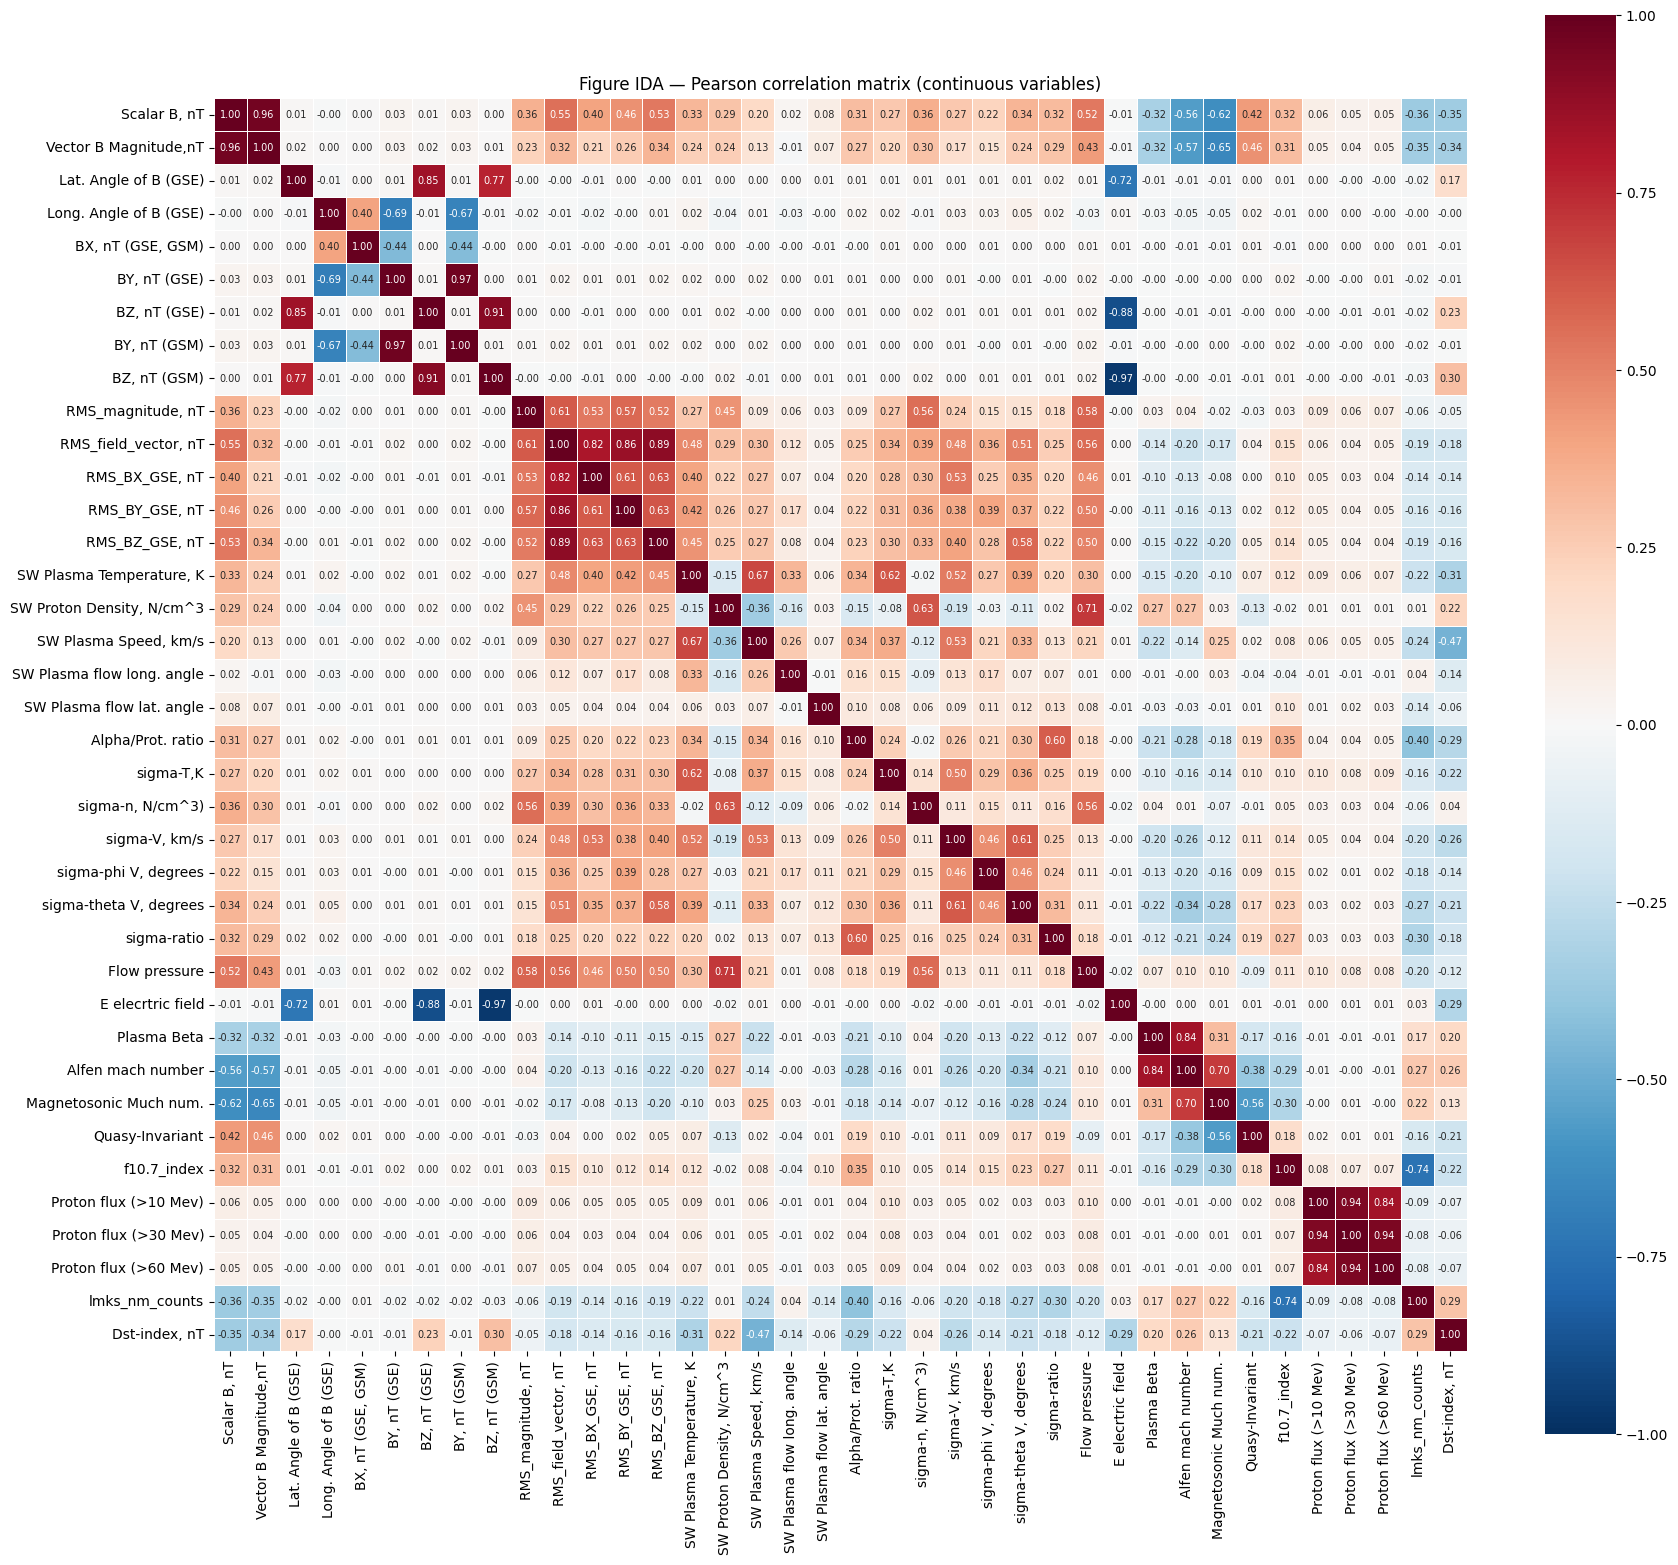

In [29]:
# ── IDA: Pearson correlation — continuous columns vs Dst ──────────────────────
# omni_lmks used — fill values replaced with NaN, LMKS aligned.
# Columns with >50% missing excluded — unreliable correlation estimates.
# Categorical, ordinal, and time columns excluded.

exclude_cols = set(omni_groups['Time'] + 
                   omni_groups['Administrative'] + 
                   omni_groups['Geomagnetic Indices'] +
                   ['Lyman_alpha', 'R (Sunspot No.)',
                    'Proton flux (>1 Mev)', 'Proton flux (>2 Mev)', 'Proton flux (>4 Mev)',
                    'Flux FLAG'])

continuous_cols = [col for col in omni_lmks.columns
                   if col not in exclude_cols
                   and col != 'Dst-index, nT'
                   and col != 'datetime'
                   and omni_lmks[col].notna().mean() > 0.5]

corr_matrix = omni_lmks[continuous_cols + ['Dst-index, nT']].corr()

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(corr_matrix, ax=ax, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Figure IDA — Pearson correlation matrix (continuous variables)', fontsize=12)
plt.tight_layout()
plt.savefig('images/fig_ida_pearson_corr.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations — Figure IDA — Pearson correlation matrix:**
>
> **Correlations with $D_{st}$:**
> - `SW Plasma Speed, km/s` (r = −0.47) — the speed of the solar wind in km/s. Faster solar wind carries more kinetic energy and compresses the magnetosphere more strongly. Speed enters the Burton injection function directly through $E_y = -V_{sw} \cdot B_z \cdot 10^{-3}$ `[BUR75]`. The correlation is the strongest among all continuous predictors — confirming solar wind speed as the primary physical driver of geomagnetic storms in the dataset.
> - `E elecrtric field` (r = −0.29) — the interplanetary electric field $E_y = -V_{sw} \cdot B_z \cdot 10^{-3}$, the direct driver of ring current injection in the Burton model `[BUR75]`. The moderate correlation is weaker than expected for the primary Burton driver — explained by the near-perfect anti-correlation with `BZ_GSM` (r = −0.97), which means $E_y$ and $B_z$ carry near-identical information with opposite signs.
> - `Flow pressure` (r = −0.29) — the dynamic pressure of the solar wind $P = \rho V^2$. Higher pressure compresses the magnetopause inward, contributing to the geomagnetic disturbance. The moderate correlation is consistent with its role as a secondary storm driver.
> - `lmks_nm_counts` (r = +0.29) — neutron monitors measure galactic cosmic rays arriving at Earth. During a geomagnetic storm, the CME shock deflects cosmic rays away from Earth (Forbush Decrease) — a stronger storm produces a deeper cosmic ray depression `[KIS25]`. The positive correlation confirms the Forbush Decrease signal is present in the 42-year record — more negative $D_{st}$ corresponds to lower neutron counts.
> - `BZ, nT (GSM)` (r = +0.30) — the north-south component of the IMF in GSM coordinates. Southward $B_z$ (negative) drives magnetic reconnection and injects energy into the magnetosphere `[BUR75]`. The positive instantaneous correlation is physically unexpected — southward $B_z$ should produce more negative $D_{st}$. This reflects the absence of a temporal lag: the Burton model operates on lagged $B_z$, not the instantaneous value. The predictive power of $B_z$ will emerge through lagged features in the pipeline.
> - `f10.7_index` (r = −0.22) — a daily index of solar radio flux measuring solar activity level. Higher $F_{10.7}$ indicates solar maximum — periods with more frequent CMEs and therefore more geomagnetic storms on average. The weak correlation reflects that $F_{10.7}$ is a long-term activity proxy, not a direct storm driver.
>
> **Redundancy:**
> - `BY, nT (GSE)` / `BY, nT (GSM)` (r = 0.97) and `BZ, nT (GSE)` / `BZ, nT (GSM)` (r = 0.91) — GSE and GSM are two coordinate systems that differ only by a rotation around the X-axis. At small tilt angles they are nearly identical — keeping both adds no new information.
> - `Plasma Beta` and `Alfvén mach number` (r = 0.84) — both depend on the ratio of plasma to magnetic energy. Plasma Beta = plasma pressure / magnetic pressure; Alfvén mach number = solar wind speed / Alfvén speed. Shared dependence on $B$ and $\rho$ drives the correlation — one of the two is sufficient.
> - `Proton flux >10, >30, >60 MeV` (r = 0.94–0.95) — three energy thresholds of the same physical process. Higher energy particles are a subset of lower energy particles — the channels are nearly redundant.
>
> **RMS columns** (r = 0.6–0.9 inter-correlation) — standard deviations of 1-minute IMF samples within each hourly average `[KIN05]`. Their mutual correlation reflects the turbulence level of the solar wind. Their near-zero correlation with $D_{st}$ confirms they carry no direct predictive signal for geomagnetic storms.
>
> **E field and BZ_GSM** (r = −0.97) — near-perfect anti-correlation, expected directly from the definition $E_y = -V_{sw} \cdot B_z \cdot 10^{-3}$ `[BUR75]`. Including both in the feature set introduces extreme multicollinearity — LASSO will select one and suppress the other.

* **Spearman Correlation — Ordinal and Discrete Variables vs $D_{st}$**

Geomagnetic indices — `Kp index`, `ap_index, nT`, `AE-index, nT`, `AL-index, nT`, `AU-index, nT`, and `pc-index` — are ordinal or discrete variables for which Pearson correlation is not appropriate. Spearman rank correlation is used instead as it makes no assumptions about linearity or scale.

In [30]:
# ── IDA: Spearman correlation — ordinal/discrete indices vs Dst ───────────────
# Pearson is not appropriate for ordinal variables [KIN05].
# Spearman rank correlation used instead.

from scipy.stats import spearmanr

ordinal_cols = ['Kp index', 'ap_index, nT', 'AE-index, nT', 'AL-index, nT', 'AU-index, nT', 'pc-index']

print(f"{'Column':<25} {'Spearman r':>12}  {'p-value':>12}")
print("─" * 52)
for col in ordinal_cols:
    data = omni_filled[['Dst-index, nT', col]].dropna()
    r, p = spearmanr(data['Dst-index, nT'], data[col])
    print(f"  {col:<23} {r:>12.3f}  {p:>12.2e}")

Column                      Spearman r       p-value
────────────────────────────────────────────────────
  Kp index                      -0.548      0.00e+00
  ap_index, nT                  -0.548      0.00e+00
  AE-index, nT                  -0.545      0.00e+00
  AL-index, nT                   0.545      0.00e+00
  AU-index, nT                  -0.463      0.00e+00
  pc-index                      -0.472      0.00e+00


> **Observations — Spearman correlation — geomagnetic indices vs $D_{st}$:**
> All six indices show strong statistically significant correlations with $D_{st}$ (|r| = 0.46–0.55, p ≈ 0 for all). Despite this, none can be used as a predictor — they are consequences of the same geomagnetic disturbance that $D_{st}$ measures, not its causes.
>
> - `Kp index` (r = −0.548) — measures how strongly Earth's magnetic field is disturbed on a global scale, computed every 3 hours from 13 ground-based magnetometers worldwide on a scale of 0–9. It describes the same ring current and magnetopause disturbance as $D_{st}$ — a different metric of the same physical phenomenon, measured simultaneously `[KIN05]`.
> - `ap_index, nT` (r = −0.548) — the linear equivalent of `Kp` in nT, derived through a deterministic conversion table. Its correlation with $D_{st}$ is identical to `Kp` because it carries exactly the same information `[KIN05]`.
> - `AE-index, nT` (r = −0.545) — measures the intensity of auroral electrojet currents flowing in the ionosphere above the polar regions. These currents are driven by the same solar wind energy input that causes $D_{st}$ depression — a direct consequence of the storm, not its cause `[WDC]`.
> - `AL-index, nT` (r = +0.545) — the minimum value of the horizontal magnetic field component from auroral magnetometers. The positive sign reflects its definition as the lower boundary of the auroral electrojet — opposite sign convention to `AE` and $D_{st}$ `[WDC]`.
> - `AU-index, nT` (r = −0.463) — the upper boundary of the auroral electrojet. Together with `AL`, it defines `AE = AU − AL` `[WDC]`.
> - `pc-index` (r = −0.472) — measures plasma convection in the polar cap driven by the interplanetary electric field. It reflects the magnetospheric response to solar wind forcing — a consequence of the same coupling that drives $D_{st}$ `[WDC]`.
>
> All six indices are ground-based measurements of storm effects — they become elevated because the storm is already happening. Including any of them as predictors would mean using the storm's own signature to predict itself — a form of data leakage that would produce artificially high model performance with no operational value.

* **Core Predictors vs $D_{st}$**

Scatter plots are used to determine the nature of the relationship between the five core predictor candidates — `BZ, nT (GSM)`, `SW Plasma Speed, km/s`, `SW Proton Density, N/cm^3`, `E elecrtric field`, and `lmks_nm_counts` — and the target ($D_{st}$). The goal is to establish three key aspects:

- **Linearity** — whether the relationship is linear or non-linear. The Burton et al. (1975) injection function $Q(E_y)$ assumes a linear relationship between $E_y$ and $\frac{dD_{st}}{dt}$ above a threshold of 0.5 mV/m `[BUR75]` — a visual check confirms whether this assumption holds in the data.
- **Saturation** — zones where at extreme solar wind values $D_{st}$ stops responding linearly. The Burton model does not account for saturation effects at very large $E_y$ `[BUR75]` — identifying these zones is important for understanding model limitations.
- **Outliers** — isolated points that deviate drastically from the general trend and may skew model weights during training.

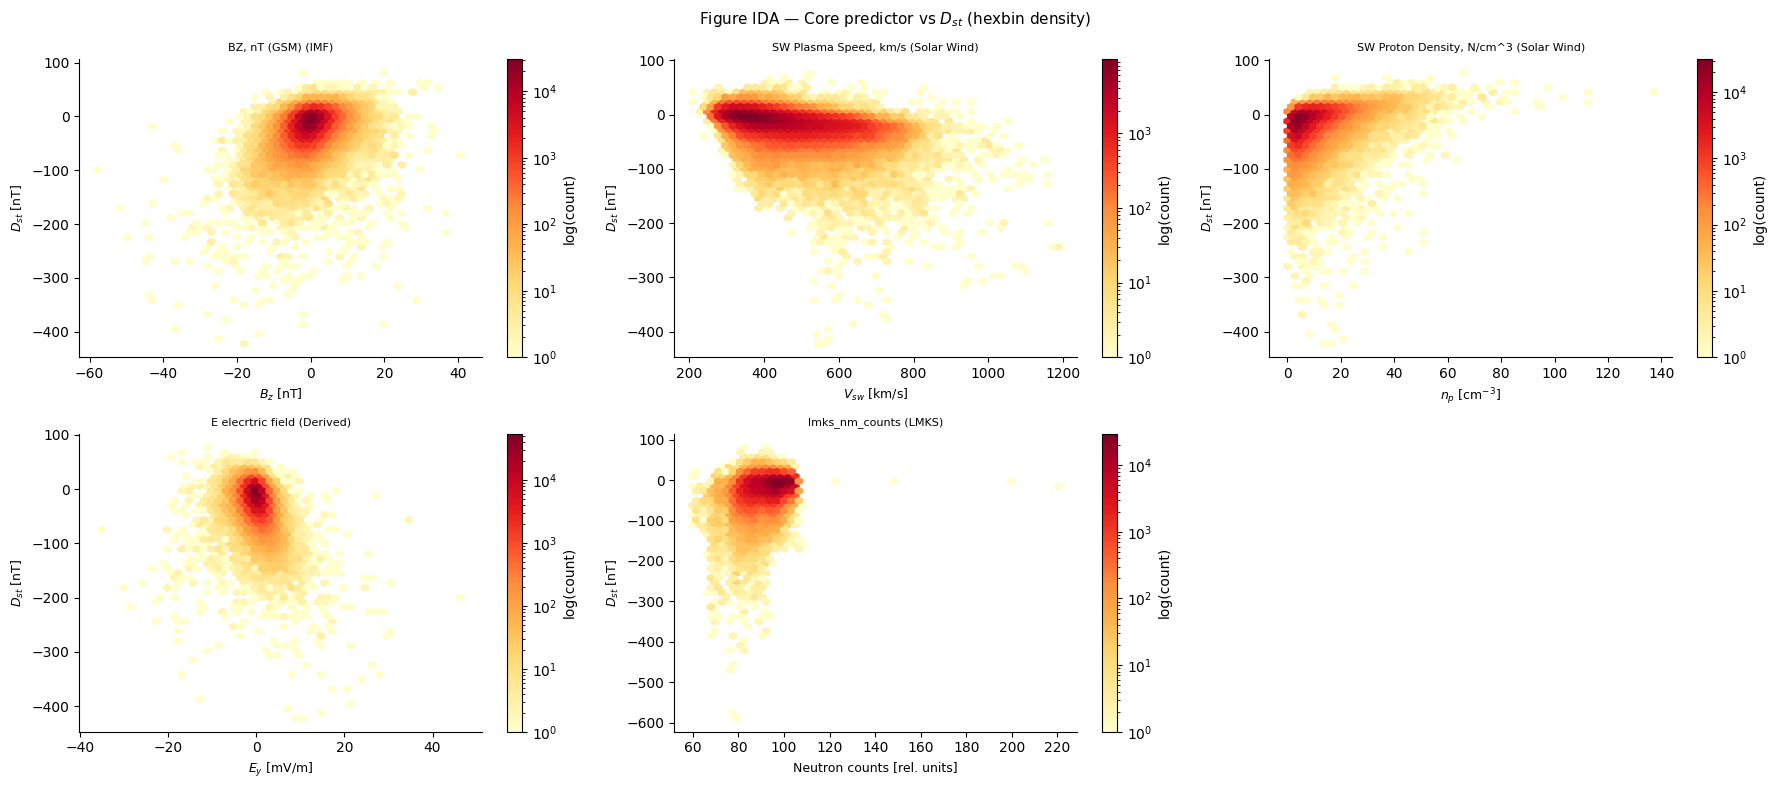

In [31]:
# ── IDA: Scatter plots — core predictors vs Dst ───────────────────────────────
# omni_lmks used — fill values replaced with NaN, LMKS aligned.
# Hexbin used to reveal density structure — scatter is dominated by quiet hours.

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for ax, (col, (group, xlabel)) in zip(axes, big5.items()):
    data = omni_lmks[['Dst-index, nT', col]].dropna()
    hb = ax.hexbin(data[col], data['Dst-index, nT'],
                   gridsize=50, cmap='YlOrRd', mincnt=1, bins='log')
    plt.colorbar(hb, ax=ax, label='log(count)')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('$D_{st}$ [nT]', fontsize=9)
    ax.set_title(f'{col} ({group})', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[5].set_visible(False)

plt.suptitle('Figure IDA — Core predictor vs $D_{st}$ (hexbin density)', fontsize=11)
plt.tight_layout()
plt.savefig('images/fig_ida_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations — Figure IDA — Core predictor vs $D_{st}$ (hexbin density):**
> - `BZ, nT (GSM)` — the high-density core clusters at $B_z \approx -10$ to $+5$ nT and $D_{st} \approx -20$ to $0$ nT. As $B_z$ becomes more negative, $D_{st}$ extends downward to −400 nT. The relationship is asymmetric — southward $B_z$ (negative) produces storm conditions while northward $B_z$ does not `[BUR75]`. Saturation is visible below $B_z \approx -20$ nT.
> - `SW Plasma Speed, km/s` — the high-density core clusters at 300–450 km/s and $D_{st} \approx 0$ nT. Above 600 km/s $D_{st}$ begins to deteriorate, with saturation visible above ~800 km/s. The relationship is non-linear — moderate speed increases have limited effect while high-speed CME events drive the strongest storms.
> - `SW Proton Density, N/cm^3` — the core clusters at 2–15 cm⁻³. At high density values the spread in $D_{st}$ increases but without a clear directional trend. This is the weakest visual relationship among the five predictors — density alone is not a reliable storm indicator.
> - `E elecrtric field` — the core clusters at −5 to +10 mV/m. Negative $E_y$ values drive $D_{st}$ depression — consistent with the Burton injection function `[BUR75]`. The relationship is asymmetric — negative $E_y$ is more effective at driving storms than positive $E_y$ of the same magnitude.
> - `lmks_nm_counts` — the core clusters at 85–100 relative units and $D_{st} \approx 0$ nT. Below 80 relative units $D_{st}$ extends to −600 nT — the Forbush Decrease signal `[KIS25]`. The relationship is non-linear — deep cosmic ray depressions correspond to the most intense storms in the record. The signal is present but diffuse, consistent with the modest $\text{PPS} = 0.22$ reported in Kisvárdai et al. (2025) `[KIS25]`.

All five predictors show non-linear relationships with $D_{st}$. The density structure confirms that quiet conditions dominate the record — the high-density core is always near $D_{st} \approx 0$ nT. Storm conditions occupy the sparse low-density tail of each distribution. Linear models will underestimate extreme storm values where the relationships saturate — this motivates the inclusion of a non-linear model alongside the linear baseline.

### Survivability Audit

The five core predictors have missing rates of 17–29% across the full 1981–2023 record. When lag features are constructed, each lagged column introduces additional missing values — a row survives only if all lag values for all predictors are present. This creates a Data Availability vs. Feature Lag tradeoff: longer lag horizons capture more of the storm memory but reduce the number of usable rows, particularly in the pre-1995 period where missing rates are already 50–75%. The audit quantifies how many rows survive `dropna()` for the full Big 5 feature set at each lag horizon, and whether the surviving rows are distributed uniformly across solar cycles or concentrated in the post-1995 period of continuous L1 coverage.

In [32]:
# ── IDA: Survivability Audit — Big 5 at different lag horizons ────────────────
# Counts rows surviving dropna() for all Big 5 columns + lag features.
# Determines whether Cycles 21+22 (1981-1994) are usable for training.

lag_horizons = [1, 6, 12, 24]

print(f"{'Lag':>6} {'Surviving rows':>16} {'% of total':>12} {'Pre-1995 rows':>15} {'Pre-1995 %':>12}")
print("─" * 65)

for lag in lag_horizons:
    df_lag = omni_lmks.copy()
    for col in big5.keys():
        df_lag[f'{col}_lag{lag}'] = df_lag[col].shift(lag)
    
    lag_cols = [f'{col}_lag{lag}' for col in big5.keys()]
    surviving = df_lag[list(big5.keys()) + lag_cols + ['Dst-index, nT']].dropna()
    
    n_total = len(surviving)
    pct_total = 100 * n_total / len(omni_lmks)
    pre1995 = surviving[surviving['datetime'].dt.year < 1995] if 'datetime' in surviving.columns else surviving[df_lag.loc[surviving.index, 'datetime'].dt.year < 1995]
    n_pre1995 = len(surviving[omni_lmks.loc[surviving.index, 'datetime'].dt.year < 1995])
    pct_pre1995 = 100 * n_pre1995 / n_total if n_total > 0 else 0
    
    print(f"  {lag:>4}h {n_total:>16,} {pct_total:>11.1f}% {n_pre1995:>15,} {pct_pre1995:>11.1f}%")

   Lag   Surviving rows   % of total   Pre-1995 rows   Pre-1995 %
─────────────────────────────────────────────────────────────────
     1h          283,818        77.7%          40,076        14.1%
     6h          273,425        74.9%          30,932        11.3%
    12h          269,328        73.7%          27,750        10.3%
    24h          271,162        74.2%          30,712        11.3%


> **Observations — Survivability Audit:**
> - At all lag horizons 74–78% of rows survive `dropna()` — the missing data in Big 5 reduces the usable record by approximately one quarter.
> - Pre-1995 rows account for 10–14% of surviving rows across all lag horizons (~27,000–40,000 rows). This is unexpected given the 50–75% missing rates observed in Figure IDA-3 for 1981–1994.
> - The surviving pre-1995 rows likely originate from 1981–1982 (ISEE-3 coverage) and isolated IMP-8 intervals. A year-by-year breakdown is required to confirm their origin and assess whether they represent sufficient quality for model training.

In [33]:
# ── IDA: Survivability Audit — pre-1995 rows by year ─────────────────────────
# Which years contribute the surviving pre-1995 rows at lag=24h?

df_lag24 = omni_lmks.copy()
for col in big5.keys():
    df_lag24[f'{col}_lag24'] = df_lag24[col].shift(24)

lag24_cols = [f'{col}_lag24' for col in big5.keys()]
surviving_24 = df_lag24[list(big5.keys()) + lag24_cols + ['Dst-index, nT', 'datetime']].dropna()

pre1995 = surviving_24[surviving_24['datetime'].dt.year < 1995]
year_counts = pre1995.groupby(pre1995['datetime'].dt.year).size()

print(f"Pre-1995 surviving rows by year (lag=24h):")
print(f"{'Year':>6} {'Rows':>8}  {'%':>6}")
print("─" * 25)
for year, count in year_counts.items():
    pct = 100 * count / len(pre1995)
    print(f"  {year:>4} {count:>8,}  {pct:>5.1f}%")
print(f"\n  Total: {len(pre1995):,} rows")

Pre-1995 surviving rows by year (lag=24h):
  Year     Rows       %
─────────────────────────
  1981      527    1.7%
  1982    4,280   13.9%
  1983    1,866    6.1%
  1984    1,148    3.7%
  1985    1,657    5.4%
  1986    2,533    8.2%
  1987    2,585    8.4%
  1988    2,671    8.7%
  1989    2,825    9.2%
  1990    2,420    7.9%
  1991    2,293    7.5%
  1992    2,008    6.5%
  1993    1,530    5.0%
  1994    2,369    7.7%

  Total: 30,712 rows


> **Observations — Pre-1995 surviving rows by year (lag=24h):**
> - 1981 contributes only 527 rows — the dataset starts in December 1981, giving only one month of data.
> - 1982 contributes 4,280 rows — the ISEE-3 period with the most complete coverage before the L1 gap.
> - 1983–1994 contribute between 1,148 and 2,825 rows per year despite the 50–75% missing rates observed in Figure IDA-3. This reflects IMP-8 intervals with sufficient coverage to produce complete Big 5 records — the missing rate is high but not 100%.
> - The pre-1995 surviving rows are sparse and unevenly distributed — an average of ~2,200 rows per year compared to ~20,000 rows per year after 1995. Including these years in training introduces a severe imbalance between solar cycle coverage — Cycles 21 and 22 would be represented by ~5% of the post-1995 annual average.

The Survivability Audit confirms that the pre-1995 period is structurally underrepresented — an average of ~2,200 rows per year compared to ~20,000 rows per year after 1995. Including Cycles 21 and 22 in training would introduce a severe imbalance in solar cycle coverage.

### Anomalies

Anomalous values — measurements that deviate significantly from the typical range — are identified and characterised in both records. Two physically distinct types of anomalies are present: Ground Level Enhancements (GLEs) and Forbush Decreases in the LMKS neutron monitor record, and extreme geomagnetic storms in the $D_{st}$ record.

The most extreme $D_{st}$ values in the record are identified to characterise the upper boundary of storm intensity and to verify that these events are physically documented in the literature.

In [34]:
# ── IDA: Extreme Dst events — identify the most negative hourly values ────────
# Fill values are already replaced with NaN in omni_filled.
# The datetime column is used to associate each extreme value with a date.

dst_series = omni_filled[['datetime', 'Dst-index, nT']].dropna()
dst_series = dst_series.sort_values('Dst-index, nT').head(20)

print("=== Top 20 most negative Dst values ===")
print(dst_series.to_string(index=False))


=== Top 20 most negative Dst values ===
           datetime  Dst-index, nT
1989-03-14 01:00:00           -589
1989-03-14 00:00:00           -583
1989-03-13 23:00:00           -472
1989-03-14 02:00:00           -463
2003-11-20 21:00:00           -422
2003-11-20 20:00:00           -422
1989-03-13 22:00:00           -418
2003-11-20 19:00:00           -413
2003-11-20 22:00:00           -405
2003-11-20 18:00:00           -396
2001-03-31 08:00:00           -387
1989-03-14 03:00:00           -386
2003-10-30 22:00:00           -383
1989-03-13 21:00:00           -382
2004-11-08 06:00:00           -374
2003-10-30 23:00:00           -371
2004-11-08 05:00:00           -368
1991-11-09 01:00:00           -354
2003-10-30 00:00:00           -353
2001-03-31 07:00:00           -351


> **Observations — extreme $D_{st}$ events:**
> The 20 most negative hourly $D_{st}$ values cluster around four distinct storm events:
> - **March 1989** — the most intense storm in the record, reaching $D_{st} = -589\ \text{nT}$ on 14 March 1989. Eight of the top 20 values belong to this event.
> - **November 2003** — the Halloween storm of 20 November 2003, reaching $D_{st} = -422\ \text{nT}$. Six of the top 20 values belong to this event.
> - **October 2003** — a separate Halloween storm on 30 October 2003, reaching $D_{st} = -383\ \text{nT}$.
> - **March 2001** and **November 2004** — two additional extreme events reaching $D_{st} \approx -387\ \text{nT}$ and $-374\ \text{nT}$ respectively.
>
> All five events fall within solar cycles 22 and 23. The extreme storm activity is concentrated in a narrow subset of the 42-year record — the rarest and most physically significant events for the modelling task.

The five extreme storm events are visualised in context — showing the $D_{st}$ profile and the corresponding LMKS neutron count rate around each event.


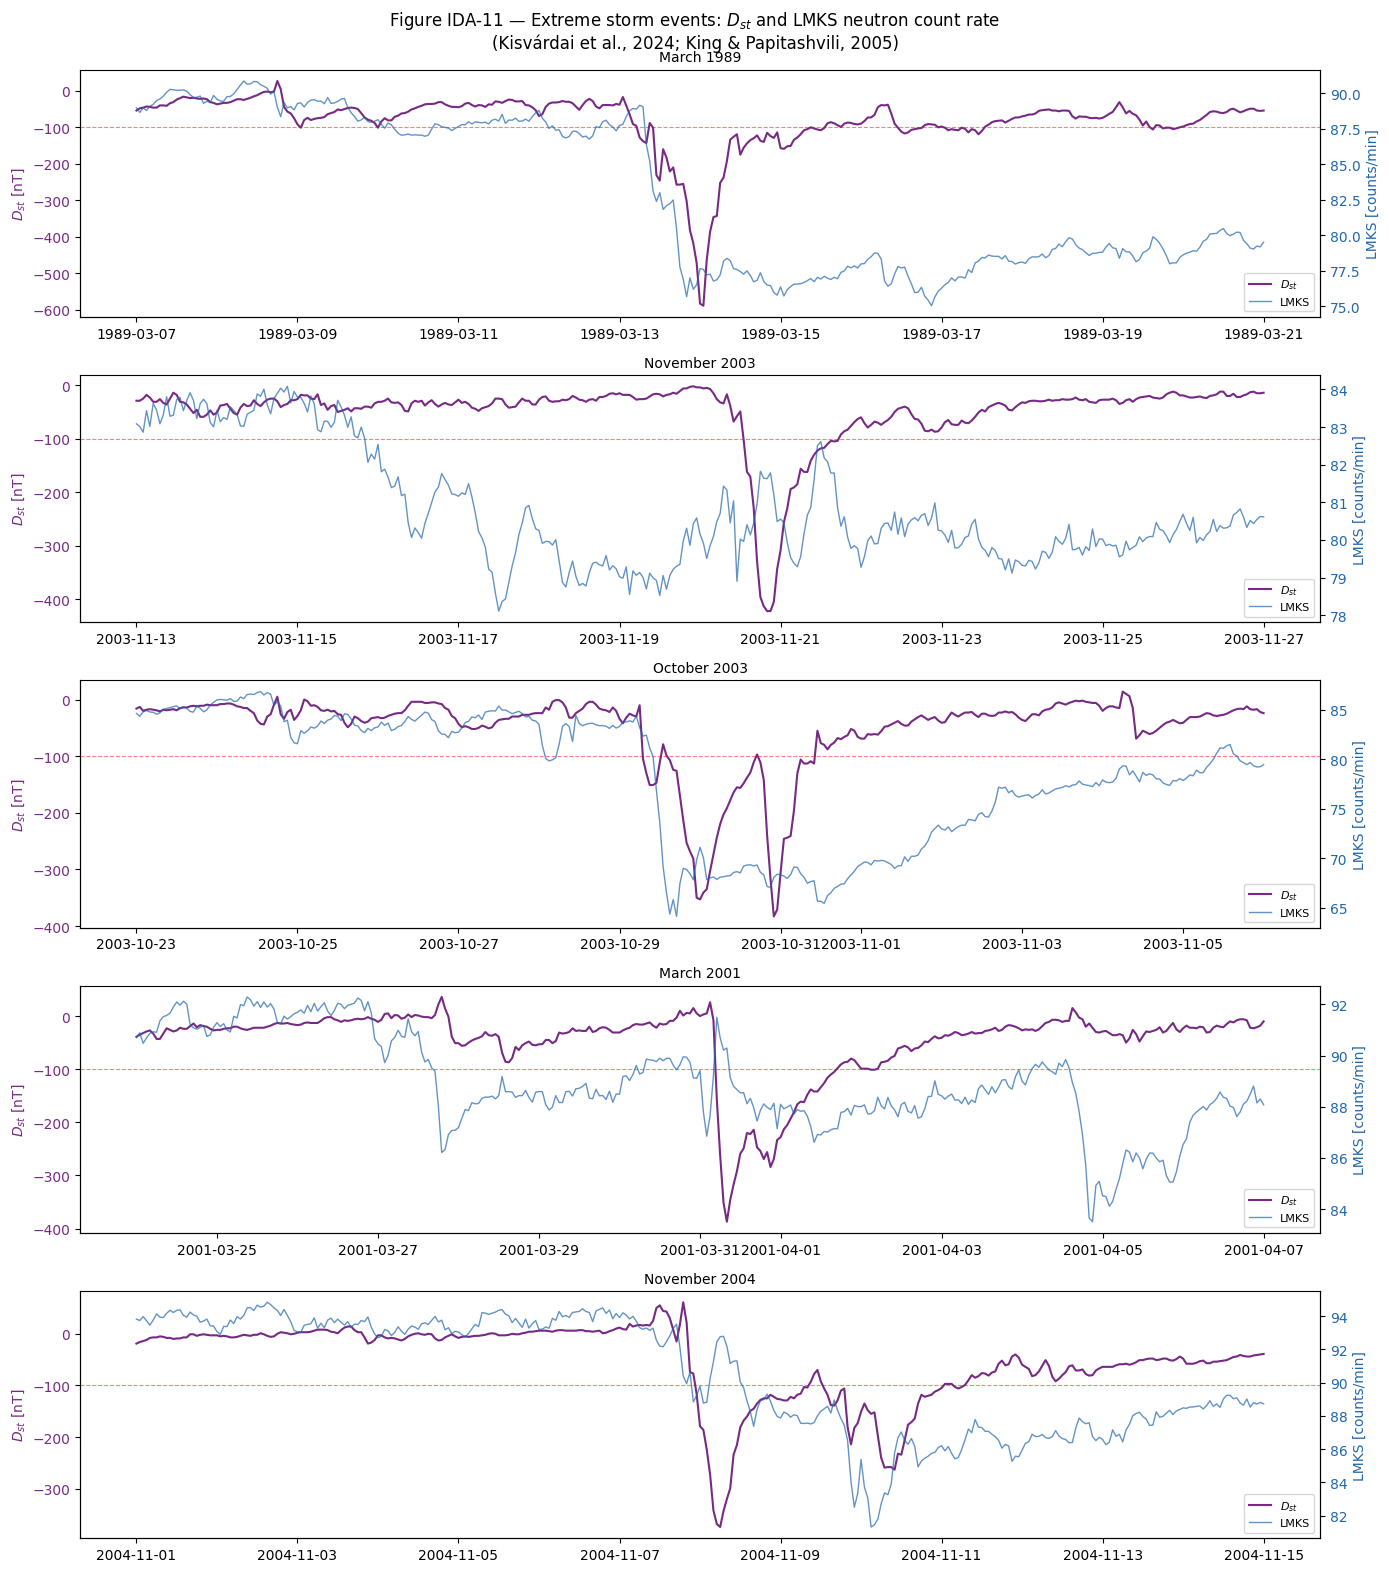

In [35]:
# ── IDA: Extreme storm events — Dst and LMKS profiles ────────────────────────
# Each panel shows a ±7 day window around the storm minimum.
# Dual Y-axis used deliberately to show temporal dynamics between Dst and LMKS.
# Note: the two axes have different scales and units.

events = [
    ('1989-03-14', 'March 1989'),
    ('2003-11-20', 'November 2003'),
    ('2003-10-30', 'October 2003'),
    ('2001-03-31', 'March 2001'),
    ('2004-11-08', 'November 2004'),
]

df_lmks_dt = df_lmks.copy()
df_lmks_dt['datetime'] = pd.to_datetime(df_lmks_dt['datetime'])

fig, axes = plt.subplots(len(events), 1, figsize=(14, 16), sharex=False)

for ax, (date_str, label) in zip(axes, events):
    center = pd.Timestamp(date_str)
    start  = center - pd.Timedelta(days=7)
    end    = center + pd.Timedelta(days=7)

    mask_dst   = (omni_filled['datetime'] >= start) & (omni_filled['datetime'] <= end)
    dst_event  = omni_filled.loc[mask_dst, ['datetime', 'Dst-index, nT']]

    mask_lmks  = (df_lmks_dt['datetime'] >= start) & (df_lmks_dt['datetime'] <= end)
    lmks_event = df_lmks_dt.loc[mask_lmks, ['datetime', 'lmks_nm_counts']]

    ax_twin = ax.twinx()

    ax.plot(dst_event['datetime'], dst_event['Dst-index, nT'],
            color='#762a83', lw=1.5, label='$D_{st}$')
    ax.axhline(-100, color='red', lw=0.8, ls='--', alpha=0.5)
    ax.set_ylabel('$D_{st}$ [nT]', color='#762a83')
    ax.tick_params(axis='y', labelcolor='#762a83')

    ax_twin.plot(lmks_event['datetime'], lmks_event['lmks_nm_counts'],
                 color='#2166ac', lw=1.0, alpha=0.7, label='LMKS')
    ax_twin.set_ylabel('LMKS [counts/min]', color='#2166ac')
    ax_twin.tick_params(axis='y', labelcolor='#2166ac')

    ax.set_title(label, fontsize=10)
    ax.spines['top'].set_visible(False)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax_twin.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='lower right')

plt.suptitle('Figure IDA-11 — Extreme storm events: $D_{st}$ and LMKS neutron count rate\n(Kisvárdai et al., 2024; King & Papitashvili, 2005)', fontsize=12)
plt.tight_layout()
plt.savefig('images/fig_ida11_extreme_storms.png', dpi=150, bbox_inches='tight')
plt.show()



> **Note:** These plots use a dual Y-axis to show both $D_{st}$ and LMKS neutron count rate in the same panel. This layout is chosen deliberately to demonstrate the temporal dynamics between the two signals — the Forbush Decrease in LMKS and the storm main phase in $D_{st}$. The two axes have different scales and units and should not be compared in magnitude.

**Observations — Figure IDA-12:**

**March 1989** — the most intense storm in the record ($D_{st} = -589\ \text{nT}$). The LMKS neutron count rate shows a clear suppression beginning several days before the storm minimum — a textbook Forbush Decrease precursor `[KIS25]`. The recovery phase of both signals is visible after 14 March.

**November 2003** — the second most intense event ($D_{st} = -422\ \text{nT}$). A gradual Forbush Decrease is visible in LMKS starting around 17 November — approximately 3 days before the storm minimum on 20 November. The neutron count rate reaches its minimum close to the storm peak.

**October 2003** — the Halloween storm of 30 October ($D_{st} = -383\ \text{nT}$). A sharp Forbush Decrease is visible in LMKS around 28–29 October — consistent with the CME shock arrival at LMKS before the storm onset.

**March 2001** ($D_{st} = -387\ \text{nT}$). The LMKS signal shows a suppression before the storm minimum, though the pattern is less clean than in 1989 — consistent with a different CME geometry relative to the LMKS observer location `[KIS25]`.

**November 2004** ($D_{st} = -374\ \text{nT}$). A Forbush Decrease is visible in LMKS around 7–8 November, preceding the storm minimum by approximately 1–2 days.

Across all five events, the LMKS neutron count rate shows a suppression that precedes or coincides with the storm main phase — qualitatively consistent with the Forbush Decrease mechanism `[KIS25]`. The lead time and amplitude vary between events, reflecting differences in CME geometry and propagation direction.

* **Special Events — GLE and Forbush Decreases**

The LMKS neutron count rate contains two physically distinct types of extreme events: Ground Level Enhancements (GLEs) — sudden increases caused by solar energetic protons — and Forbush Decreases — transient suppressions caused by approaching CME shocks. We identify and characterise both.

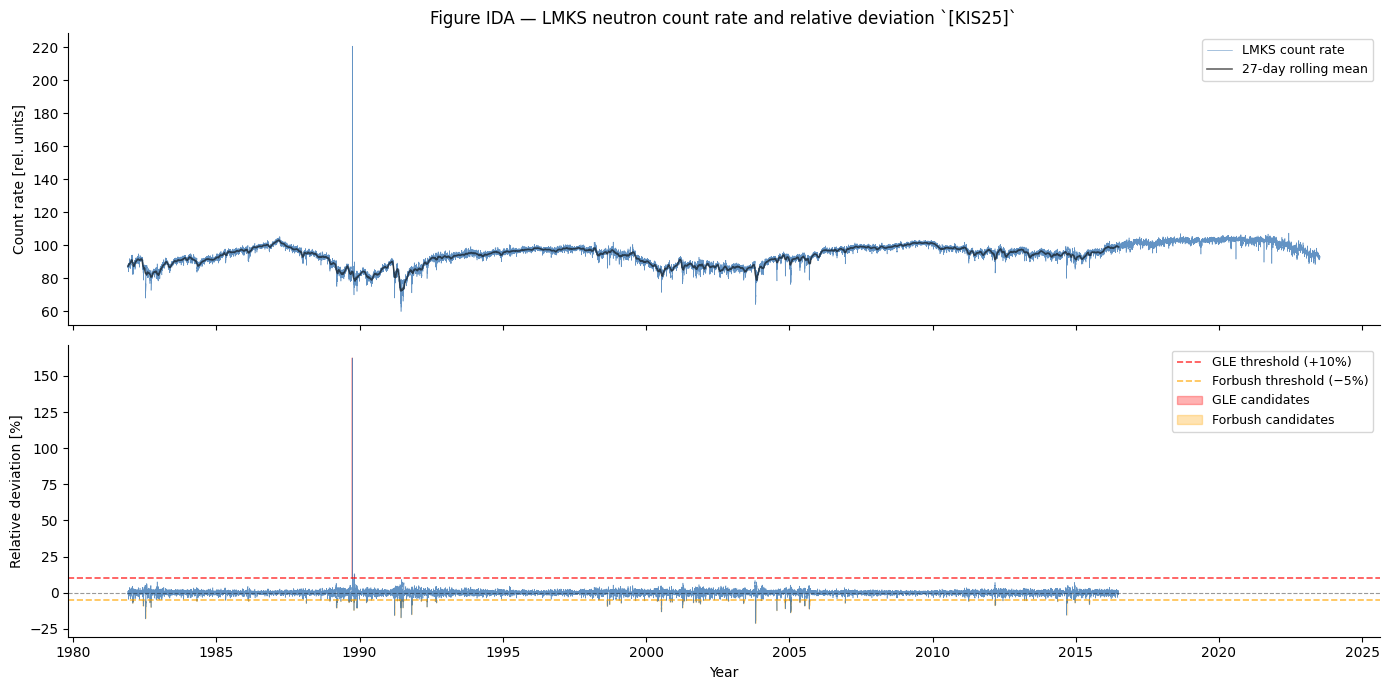

=== Relative deviation statistics ===
count    303133.00
mean         -0.00
std           1.47
min         -21.29
25%          -0.61
50%           0.08
75%           0.73
max         162.40
dtype: float64

GLE candidates (delta > +10%):    8 hours
Forbush candidates (delta < -5%): 2185 hours


In [36]:
# ── GLE and Forbush Decrease — visual identification ─────────────────────────
# Rolling 27-day baseline (one solar rotation) — scipy uniform_filter for speed.
# GLE threshold: +10% above baseline [KIS25].
# Forbush threshold: -5% below baseline [KIS25].

from scipy.ndimage import uniform_filter1d

counts    = df_lmks['lmks_nm_counts'].values
baseline  = uniform_filter1d(counts, size=27*24, mode='reflect')
delta_pct = 100 * (counts - baseline) / baseline
dt        = pd.to_datetime(df_lmks['datetime'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Raw count rate
ax1.plot(dt, counts, color='#2166ac', lw=0.4, alpha=0.7, label='LMKS count rate')
ax1.plot(dt, baseline, color='black', lw=1.2, alpha=0.6, label='27-day rolling mean')
ax1.set_ylabel('Count rate [rel. units]')
ax1.set_title('Figure IDA — LMKS neutron count rate and relative deviation `[KIS25]`')
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Relative deviation
ax2.plot(dt, delta_pct, color='#2166ac', lw=0.4, alpha=0.7)
ax2.axhline(0,  color='black',  lw=0.8, ls='--', alpha=0.4)
ax2.axhline(10, color='red',    lw=1.2, ls='--', alpha=0.7, label='GLE threshold (+10%)')
ax2.axhline(-5, color='orange', lw=1.2, ls='--', alpha=0.7, label='Forbush threshold (−5%)')
ax2.fill_between(dt, delta_pct, 10,
                 where=(delta_pct > 10), color='red', alpha=0.3, label='GLE candidates')
ax2.fill_between(dt, delta_pct, -5,
                 where=(delta_pct < -5), color='orange', alpha=0.3, label='Forbush candidates')
ax2.set_ylabel('Relative deviation [%]')
ax2.set_xlabel('Year')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('images/fig_ida_gle_forbush.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Relative deviation statistics ===")
print(pd.Series(delta_pct).describe().round(2))
print(f"\nGLE candidates (delta > +10%):    {(delta_pct > 10).sum()} hours")
print(f"Forbush candidates (delta < -5%): {(delta_pct < -5).sum()} hours")

> **Observations — Figure IDA:**
> - **GLE events:** Only 8 hours exceed the +10% threshold across the 42-year record. The dominant spike — reaching +162% relative deviation — occurs around 29 September 1989, consistent with the largest GLE recorded at LMKS `[KIS25]`. The event is extremely impulsive — a single spike visible in the upper panel reaching ~220 relative units against a baseline of ~95.
> - **Forbush Decreases:** 2,185 hours fall below the −5% threshold — distributed throughout the record with notable concentrations around solar maxima (1989–1991, 2001–2003). The minimum relative deviation is −21.3%, corresponding to the deepest Forbush Decrease in the record.
> - **Solar cycle modulation:** The 27-day rolling mean shows the long-term solar cycle — lower count rates during solar maxima (stronger cosmic ray shielding) and higher rates during solar minima. The 11-year cycle is clearly visible in the baseline.

> **Summary — Anomalies:**
> The anomaly analysis reveals two physically distinct signals in the LMKS record — Ground Level Enhancements (GLEs) and Forbush Decreases — and confirms the extreme storm events in $D_{st}$.
>
> The 8 GLE hours represent high-impact, low-frequency solar energetic particle events where neutron counts increase sharply — the opposite signal to a Forbush Decrease. These hours carry a physically different meaning and require separate treatment. A model trained without awareness of this distinction may learn to treat GLE hours as anomalous outliers and suppress them, despite their physical significance for extreme storm prediction.
>
> The 2,185 Forbush Decrease hours show neutron count suppression preceding or coinciding with geomagnetic storm onset — confirmed visually across all five extreme storm events in Figure IDA-11. The lead time of 7–21 hours `[KIS25]` motivates the use of lagged `lmks_nm_counts` features in the pipeline.
>
> The five extreme $D_{st}$ events are concentrated in Solar Cycles 22 and 23. No storm below −300 nT is present in Cycles 24+25 — the period reserved for testing. This structural difference between training and test periods is a known limitation of the dataset and will affect model evaluation on the most extreme events.

### Summary

#### Data Quality

The OMNI record spans 365,232 hourly observations from December 1981 to July 2023. Missing data is not random — it is structurally concentrated in the pre-1995 period when no dedicated solar wind monitor was stationed at the L1 point `[KIN05]`. After 1995, missing rates drop to near zero across all physical groups. The only systematic post-1995 exceptions are `Alpha/Prot. ratio` (gap after 2018 `[KIN05]`) and the Proton Flux group (100% missing after 2020 `[KIN05]`). Fill values have been replaced with `NaN` in `omni_filled`. The `Flux FLAG` column identifies 3,757 hours of magnetospheric contamination in the proton flux channels and is excluded from the feature set to avoid target leakage. The `Dst-index, nT` target variable is available for 100% of the record with no fill values `[KIN05]`.

#### Feature Candidates

The following columns are retained as continuous physical predictor candidates after IDA:

- **IMF:** `Scalar B`, `BX`, `BY_GSM`, `BZ_GSM`
- **Solar Wind:** `SW Plasma Speed`, `SW Proton Density`, `SW Plasma Temperature`, `Alpha/Prot. ratio`
- **Derived:** `Flow pressure`, `E elecrtric field`, `Plasma Beta`, `Alfvén mach`, `Magnetosonic mach`, `Quasy-Invariant`
- **Solar Activity:** `f10.7_index`
- **Proton Flux:** `Proton flux >10, >30, >60 MeV`
- **LMKS:** `lmks_nm_counts`

#### Excluded Columns

- **Target leakage:** `Kp index`, `ap_index`, `AE-index`, `AL-index`, `AU-index`, `pc-index` — ground-based consequences of the same magnetospheric disturbance as `Dst`
- **Categorical:** `Flux FLAG`, `ID for IMF spacecraft`, `ID for SW Plasma spacecraft` — nominal codes with no physical magnitude
- **Quality indicators:** Sigma (6 columns), RMS (5 columns) — standard deviations of the averaging process `[KIN05]`
- **Redundant:** `BY_GSE`, `BZ_GSE` — near-identical to GSM components (r = 0.97, 0.91)
- **Constant:** `Lyman_alpha` — std = 0.00 across the entire record
- **High missing:** `Proton flux >1, >2, >4 MeV` — 64.1% missing
- **Administrative:** Time columns, Bartels rotation number, point counts

#### Key Findings

`SW Plasma Speed` shows the strongest Pearson correlation with `Dst` (r = −0.47) among the continuous predictors `[BUR75]`. `BZ_GSM` shows a counterintuitive positive instantaneous correlation (r = +0.30) — consistent with the absence of a temporal lag in the Burton model `[BUR75]`. `lmks_nm_counts` shows r = +0.29 with `Dst` — the Forbush Decrease signal confirmed visually across all five extreme storm events. All five core predictors show non-linear relationships with `Dst` — saturation is visible at extreme values for all predictors. The pre-1995 period contributes ~2,200 surviving rows per year after lag feature construction, compared to ~20,000 per year after 1995 — a structural imbalance in solar cycle coverage.

Past values of `Dst` are strongly autocorrelated (r ≈ 0.98 at lag 1h, r ≈ 0.53 at lag 24h) — autoregressive features `Dst(t-h)` are physically motivated by the Burton ring current decay time $\tau \approx 7.7$ hours `[BUR75]`. The differential neutron flux $\delta n(t) = (N(t) - N(t-w)) / N(t-w)$ — defined in Methods — captures the rate of change of the cosmic ray signal rather than its absolute level, making it a more sensitive indicator of an approaching Forbush Decrease `[KIS25]`.

## Data Preparation

The Data Preparation section transforms the raw source datasets into an analysis-ready format. It is divided into two subsections: Data Cleaning, which removes invalid measurements, excludes irrelevant columns, and joins the two source datasets; and Feature Engineering, which constructs derived variables including lag features, time derivatives, and temporal encodings used in modelling.

### Data Cleaning

The raw OMNI and LMKS datasets contain invalid measurements, redundant columns, and physically irrelevant variables documented in the IDA section. The goal of this step is to produce a single joined dataset `analysis_data` containing only physically valid measurements with missing values encoded as `NaN`. No imputation is applied at this stage — missing values are retained to preserve the true data availability for downstream feature engineering.

In [53]:
# ── Data Loading ──────────────────────────────────────────────────────────────
# Column names parsed from OMNI format file [KIN05].

col_names = pd.read_fwf('data/input/omni2_6HWKguLfs2.fmt', skiprows=4, header=None)[1].tolist()
omni_data = pd.read_csv('data/input/omni2_6HWKguLfs2.lst', sep=r'\s+', header=None, names=col_names)
print("\n=== OMNI — shape ===")
print(omni_raw.shape)


lmks_data = pd.read_csv('data/input/LMKS_NM_1981-2023_h.csv')
print("\n=== LMKS — first 5 rows ===")
print(lmks_raw.shape)



=== OMNI — shape ===
(365232, 57)

=== LMKS — first 5 rows ===
(364728, 2)


#### Column Renaming

The raw OMNI column names contain special characters, units, and coordinate system labels that are incompatible with standard Python attribute access and downstream pipeline code. 

In [54]:
# ── Data Cleaning: Column Renaming ────────────────────────────────────────────
# Raw OMNI column names contain special characters incompatible with Python.
# Explicit mapping for all 57 columns [KIN05].

col_rename = {
    'YEAR': 'year', 'DOY': 'doy', 'Hour': 'hour',
    'Bartels rotation number': 'bartels',
    'ID for IMF spacecraft': 'id_imf_sc',
    'ID for SW Plasma spacecraft': 'id_sw_sc',
    '# of points in IMF averages': 'n_imf',
    '# of points in Plasma averag.': 'n_plasma',
    'Scalar B, nT': 'b_scalar', 'Vector B Magnitude,nT': 'b_vector',
    'Lat. Angle of B (GSE)': 'b_lat_gse', 'Long. Angle of B (GSE)': 'b_lon_gse',
    'BX, nT (GSE, GSM)': 'bx_gse', 'BY, nT (GSE)': 'by_gse', 'BZ, nT (GSE)': 'bz_gse',
    'BY, nT (GSM)': 'by_gsm', 'BZ, nT (GSM)': 'bz_gsm',
    'RMS_magnitude, nT': 'rms_b', 'RMS_field_vector, nT': 'rms_bvec',
    'RMS_BX_GSE, nT': 'rms_bx', 'RMS_BY_GSE, nT': 'rms_by', 'RMS_BZ_GSE, nT': 'rms_bz',
    'SW Plasma Temperature, K': 'sw_temp', 'SW Proton Density, N/cm^3': 'sw_density',
    'SW Plasma Speed, km/s': 'sw_speed', 'SW Plasma flow long. angle': 'sw_phi',
    'SW Plasma flow lat. angle': 'sw_theta', 'Alpha/Prot. ratio': 'alpha_prot',
    'sigma-T,K': 'sigma_t', 'sigma-n, N/cm^3)': 'sigma_n', 'sigma-V, km/s': 'sigma_v',
    'sigma-phi V, degrees': 'sigma_phi', 'sigma-theta V, degrees': 'sigma_theta',
    'sigma-ratio': 'sigma_ratio', 'Flow pressure': 'sw_pressure',
    'E elecrtric field': 'e_field', 'Plasma Beta': 'plasma_beta',
    'Alfen mach number': 'mach_alfven', 'Magnetosonic Much num.': 'mach_ms',
    'Quasy-Invariant': 'qi', 'Kp index': 'kp', 'R (Sunspot No.)': 'ssn',
    'Dst-index, nT': 'dst', 'ap_index, nT': 'ap', 'f10.7_index': 'f107',
    'AE-index, nT': 'ae', 'AL-index, nT': 'al', 'AU-index, nT': 'au',
    'pc-index': 'pc', 'Lyman_alpha': 'lyman_alpha',
    'Proton flux (>1 Mev)': 'pf_1mev', 'Proton flux (>2 Mev)': 'pf_2mev',
    'Proton flux (>4 Mev)': 'pf_4mev', 'Proton flux (>10 Mev)': 'pf_10mev',
    'Proton flux (>30 Mev)': 'pf_30mev', 'Proton flux (>60 Mev)': 'pf_60mev',
    'Flux FLAG': 'flux_flag',
}

missing = [c for c in omni_data.columns if c not in col_rename]
omni_data = omni_data.rename(columns=col_rename)

print(f"omni_data shape:    {omni_data.shape}")
print(f"Unmapped columns:   {missing}")

omni_data shape:    (365232, 57)
Unmapped columns:   []


In [55]:
lmks_data = lmks_data.copy()
lmks_data['datetime'] = pd.to_datetime(lmks_data['datetime'])
lmks_data = lmks_data.rename(columns={'lmks_nm_counts': 'neutron_counts'})

print(f"lmks_data shape: {lmks_data.shape}")
print(f"Columns: {lmks_data.columns.tolist()}")
print(f"dtypes:\n{lmks_data.dtypes}")

lmks_data shape: (364728, 2)
Columns: ['datetime', 'neutron_counts']
dtypes:
datetime          datetime64[ns]
neutron_counts           float64
dtype: object


#### Fill Value Replacement

The OMNI dataset encodes missing measurements as sentinel fill values — physically impossible numbers that exactly fill the allocated field width in the fixed-width ASCII format `[KIN05]`. The fill values for each column were identified in the IDA Value Ranges & Distributions analysis and are explicitly defined here. Columns with physically valid maximum values — `dst`, `kp`, `ssn`, `ap`, and `lyman_alpha` — are excluded from replacement as documented in the IDA conclusions.

In [61]:
# ── Data Cleaning: Fill Value Replacement ─────────────────────────────────────
# Fill values identified in IDA Value Ranges & Distributions analysis.
# Cross-validated against King & Papitashvili (2005) [KIN05].
# Columns with physically valid max values excluded (dst, kp, ssn, ap, lyman_alpha).

fill_map = {
    # IMF — uniform fill value 999.9 [KIN05]
    'b_scalar': 999.9, 'b_vector': 999.9, 'b_lat_gse': 999.9, 'b_lon_gse': 999.9,
    'bx_gse': 999.9, 'by_gse': 999.9, 'bz_gse': 999.9,
    'by_gsm': 999.9, 'bz_gsm': 999.9,
    'rms_b': 999.9, 'rms_bvec': 999.9, 'rms_bx': 999.9, 'rms_by': 999.9, 'rms_bz': 999.9,
    # Solar Wind Plasma [KIN05]
    'sw_temp': 9999999.0, 'sw_density': 999.9, 'sw_speed': 9999.0,
    'sw_phi': 999.9, 'sw_theta': 999.9, 'alpha_prot': 9.999,
    # Sigma [KIN05]
    'sigma_t': 9999999.0, 'sigma_n': 999.9, 'sigma_v': 9999.0,
    'sigma_phi': 999.9, 'sigma_theta': 999.9, 'sigma_ratio': 9.999,
    # Derived [KIN05]
    'sw_pressure': 99.99, 'e_field': 999.99, 'plasma_beta': 999.99,
    'mach_alfven': 999.9, 'mach_ms': 99.9, 'qi': 9.9999,
    # Solar Activity [KIN05]
    'f107': 999.9,
    # Geomagnetic Indices [KIN05]
    'ae': 9999, 'al': 99999, 'au': 99999, 'pc': 999.9,
    # Proton Flux [KIN05]
    'pf_1mev': 999999.99, 'pf_2mev': 99999.99, 'pf_4mev': 99999.99,
    'pf_10mev': 99999.99, 'pf_30mev': 99999.99, 'pf_60mev': 99999.99,
    # Flux FLAG — fill is minimum, not maximum [KIN05]
    'flux_flag': -1,
}

for col, fv in fill_map.items():
    omni_data[col] = omni_data[col].replace(fv, np.nan)

omni_data['datetime'] = pd.to_datetime(
    omni_data['year'].astype(str) + ' ' +
    omni_data['doy'].astype(str) + ' ' +
    omni_data['hour'].astype(str), format='%Y %j %H'
).astype('datetime64[ns]')


print(f"fill_map:      {len(fill_map)} columns")
print(f"omni_data NaN: {omni_data.isnull().sum().sum():,}")

fill_map:      44 columns
omni_data NaN: 3,613,308


#### Dataset Consolidation

The OMNI and LMKS datasets are aligned on the `datetime` column to produce a single unified record. The LMKS dataset starts on 1981-12-01 and determines the left boundary of the consolidated record. The result is a single dataframe `analysis_data` containing simultaneous measurements from both instruments for every hour in the overlapping period.

In [37]:
# ── Data Loading ──────────────────────────────────────────────────────────────
# Column names parsed from OMNI format file [KIN05].

col_names = pd.read_fwf('data/input/omni2_6HWKguLfs2.fmt', skiprows=4, header=None)[1].tolist()
omni_raw = pd.read_csv('data/input/omni2_6HWKguLfs2.lst', sep=r'\s+', header=None, names=col_names)
print("\n=== OMNI — shape ===")
print(omni_raw.shape)


lmks_raw = pd.read_csv('data/input/LMKS_NM_1981-2023_h.csv')
print("\n=== LMKS — first 5 rows ===")
print(lmks_raw.shape)



=== OMNI — shape ===
(365232, 57)

=== LMKS — first 5 rows ===
(364728, 2)


#### Structural Column Exclusion

Columns are removed from `omni_data` based on structural domain knowledge. Three categories of exclusion are applied, each motivated by a different physical or methodological reason.

**Proxy Leakage** — `kp`, `ap`, `ae`, `al`, `au`, `pc` — are ground-based indices that measure the effects of a geomagnetic storm on Earth's magnetic field and ionosphere. They are consequences of the same ring current disturbance that `dst` measures — not causes. The physical chain is: CME → L1 solar wind (predictors) → magnetosphere → ring current → `dst` (target) → ground effects → `kp`, `ap`, `ae`, `al`, `au`, `pc` (leakage). Including them would mean predicting the cause from its own consequences `[WDC]` `[KIN05]`.

**Administrative columns** — `year`, `doy`, `hour`, `bartels` — encode the timestamp and data rotation number. Temporal information is preserved in the `datetime` column constructed in the Fill Value Replacement step. The Bartels rotation number is an administrative identifier with no physical relationship to geomagnetic storm intensity `[KIN05]`.

**Constant and structurally missing columns** — `lyman_alpha` has std = 0.00 across the entire 42-year record and carries no predictive information, as documented in the IDA Value Ranges analysis. `pf_1mev`, `pf_2mev`, `pf_4mev` are 100% missing for the entire validation (2009–2019) and test (2019–2023) periods — a model trained with these columns cannot make predictions for the evaluation period, as documented in the IDA Missing Data analysis.

In [62]:
# ── Data Cleaning: Structural Column Exclusion ────────────────────────────────
# Three categories of exclusion based on domain knowledge.
# Full justification in IDA sections: Feature-Target Analysis, Missing Data,
# Value Ranges & Distributions.

proxy_leakage = ['kp', 'ap', 'ae', 'al', 'au', 'pc']

administrative = ['year', 'doy', 'hour', 'bartels']

structural_missing = ['lyman_alpha', 'pf_1mev', 'pf_2mev', 'pf_4mev']

cols_to_drop = proxy_leakage + administrative + structural_missing

omni_data = omni_data.drop(columns=cols_to_drop)

print(f"Dropped columns:    {len(cols_to_drop)}")
print(f"omni_data shape:    {omni_data.shape}")
print(f"Remaining columns:  {omni_data.columns.tolist()}")

Dropped columns:    14
omni_data shape:    (365232, 44)
Remaining columns:  ['id_imf_sc', 'id_sw_sc', 'n_imf', 'n_plasma', 'b_scalar', 'b_vector', 'b_lat_gse', 'b_lon_gse', 'bx_gse', 'by_gse', 'bz_gse', 'by_gsm', 'bz_gsm', 'rms_b', 'rms_bvec', 'rms_bx', 'rms_by', 'rms_bz', 'sw_temp', 'sw_density', 'sw_speed', 'sw_phi', 'sw_theta', 'alpha_prot', 'sigma_t', 'sigma_n', 'sigma_v', 'sigma_phi', 'sigma_theta', 'sigma_ratio', 'sw_pressure', 'e_field', 'plasma_beta', 'mach_alfven', 'mach_ms', 'qi', 'ssn', 'dst', 'f107', 'pf_10mev', 'pf_30mev', 'pf_60mev', 'flux_flag', 'datetime']


> **Observations — Structural Column Exclusion:**
> - 14 columns dropped: 6 proxy leakage, 4 administrative, 3 high missing (pf_1/2/4mev), 1 constant (lyman_alpha).
> - `omni_data` reduced from 57 to 44 columns.
> - `datetime` column retained for join with `lmks_data`.
> - Remaining columns include all physical predictors, quality indicators (sigma, rms), and `flux_flag` — these are handled in Feature Engineering.

#### Dataset Consolidation

`omni_data` and `lmks_data` are joined on the `datetime` column using an inner join. The LMKS dataset starts on 1981-12-01 and determines the left boundary of the consolidated record. The result is `analysis_data` — a single unified dataset containing simultaneous OMNI and LMKS measurements for every hour in the overlapping period.

In [64]:
# ── Data Cleaning: Dataset Consolidation ─────────────────────────────────────
# Inner join on datetime — LMKS start date (1981-12-01) determines left boundary.
# Result: analysis_data — single unified dataset for all downstream processing.

analysis_data = omni_data.merge(
    lmks_data[['datetime', 'neutron_counts']],
    on='datetime',
    how='inner'
)

print(f"omni_data rows:      {len(omni_data):>8,}")
print(f"lmks_data rows:      {len(lmks_data):>8,}")
print(f"analysis_data rows:  {len(analysis_data):>8,}")
print(f"analysis_data cols:  {len(analysis_data.columns):>8,}")
print(f"Date range: {analysis_data['datetime'].min()} → {analysis_data['datetime'].max()}")

omni_data rows:       365,232
lmks_data rows:       364,728
analysis_data rows:   364,728
analysis_data cols:        45
Date range: 1981-12-01 00:00:00 → 2023-07-10 23:00:00


> **Observations — Dataset Consolidation:**
> - `analysis_data` contains 364,728 rows × 45 columns — LMKS start date (1981-12-01) determines the left boundary, as expected.
> - 504 OMNI rows (1981-01-01 to 1981-11-30) are excluded by the inner join — consistent with the LMKS start date.
> - Date range: 1981-12-01 to 2023-07-10 — 41 years and 7 months of simultaneous measurements.
> - `neutron_counts` column successfully added from `lmks_data`.